# Stock Price Forecasting & Portfolio Allocation
### ARIMA, SARIMAX, GARCH, LSTM, GRU and Transformer — compared on 5 NSE stocks
**Capstone Project**

This notebook:
1. Downloads and cleans historical data for 5 NSE stocks.
2. Engineers return, momentum, volume and volatility features.
3. Compares ARIMA, SARIMAX, LSTM, GRU and Transformer models on a strictly time-ordered holdout set.
4. Forecasts volatility with GARCH.
5. Converts return forecasts into a volatility-scaled long/cash strategy and evaluates it against buy-and-hold.
6. Builds an inverse-volatility portfolio.

**Important:** Results are generated when the notebook is run. No performance claim is hard-coded into the notebook.


In [1]:
!pip install pmdarima arch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 37.4 MB/s eta 0:00:00


In [2]:
import warnings
import os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
from datetime import datetime

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
from arch import arch_model

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy import stats

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams["figure.figsize"] = (11, 4)
sns.set_style("whitegrid")


In [3]:

STOCKS = ["TCS.NS", "HDFCBANK.NS", "SUNPHARMA.NS", "NESTLEIND.NS", "MARUTI.NS"]

START_DATE = "2015-01-01"
END_DATE = datetime.today().strftime("%Y-%m-%d")

TEST_SIZE = 60
WINDOW = 60
EPOCHS = 80
BATCH_SIZE = 16
CAPITAL = 1_000_000

FEATURE_COLS = ["Log_Returns", "RSI", "MACD_Hist", "Vol_Ratio", "Rolling_STD"]
TARGET_COL = "Log_Returns"
VOL_THRESHOLD_MULTIPLIER = 0.5


## 2. Data Loading

Downloads each stock with `yfinance` and caches it as a CSV, so re-running the notebook doesn't
re-download data every time.

In [4]:
def load_stock(ticker, start=START_DATE, end=END_DATE):
    csv_path = f"{ticker}.csv"
    if os.path.exists(csv_path):
        data = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    else:
        data = yf.download(
            ticker, start=start, end=end,
            progress=False, auto_adjust=True
        )
        if data.empty:
            raise ValueError(f"No data returned for {ticker}.")
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        data.to_csv(csv_path)

    required = ["Close", "Volume"]
    missing = [c for c in required if c not in data.columns]
    if missing:
        raise ValueError(f"{ticker}: missing columns {missing}")

    data = data[~data.index.duplicated(keep="last")].sort_index()
    return data


raw_data = {ticker: load_stock(ticker) for ticker in STOCKS}
print({ticker: df.shape for ticker, df in raw_data.items()})


{'TCS.NS': (2882, 5), 'HDFCBANK.NS': (2882, 5), 'SUNPHARMA.NS': (2882, 5), 'NESTLEIND.NS': (2882, 5), 'MARUTI.NS': (2882, 5)}


## 3. Feature Engineering & Preprocessing

The v1 notebook only gave the deep learning models one number per day: the closing price. That's not much
for a model to work with, and it also means TCS (₹3,000+) and Maruti (₹13,000+) are on completely different
scales.

Instead, v2 builds 5 simple features that are already roughly the same scale across every stock:

- **`Log_Returns`** — how much the price moved, in %, from yesterday to today. This is also what the
  models will try to *predict* (tomorrow's return), instead of predicting the raw price.
- **`RSI`** — a 0-100 score of whether a stock has been overbought or oversold recently.
- **`MACD_Hist`** — a simple trend-strength signal.
- **`Vol_Ratio`** — is today's trading volume higher or lower than usual.
- **`Rolling_STD`** — how volatile the stock has been over the last 20 days.


In [5]:
def add_technical_features(df):
    df = df.copy()

    # All indicators are computed from information available up to each date.
    df["Returns"] = df["Close"].pct_change()
    df["Log_Returns"] = np.log(df["Close"] / df["Close"].shift(1))
    df["Rolling_STD"] = df["Returns"].rolling(20).std()

    # RSI (14 trading sessions)
    delta = df["Close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    df["RSI"] = (100 - (100 / (1 + rs))).fillna(50)

    # MACD histogram
    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()
    macd_line = ema12 - ema26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    df["MACD_Hist"] = macd_line - signal_line

    # Volume relative to its 20-session average
    df["Vol_Ratio"] = df["Volume"] / df["Volume"].rolling(20).mean()

    return df


def preprocess_stock(df, test_size=TEST_SIZE):
    df = df.copy()

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df.set_index("Date", inplace=True)
    else:
        df.index = pd.to_datetime(df.index)

    df = df.sort_index()
    df = df[~df.index.duplicated(keep="last")]

    df = add_technical_features(df)
    df = df.dropna(subset=["Close"] + FEATURE_COLS)

    if len(df) <= test_size + WINDOW:
        raise ValueError(f"Not enough observations for {test_size}-day test and {WINDOW}-day window.")

    train = df.iloc[:-test_size].copy()
    test = df.iloc[-test_size:].copy()

    return {"full": df, "train": train, "test": test}


processed = {ticker: preprocess_stock(df) for ticker, df in raw_data.items()}
print({ticker: (v["train"].shape, v["test"].shape) for ticker, v in processed.items()})


{'TCS.NS': ((2802, 11), (60, 11)), 'HDFCBANK.NS': ((2802, 11), (60, 11)), 'SUNPHARMA.NS': ((2801, 11), (60, 11)), 'NESTLEIND.NS': ((2802, 11), (60, 11)), 'MARUTI.NS': ((2802, 11), (60, 11))}


## 4. Exploratory Data Analysis

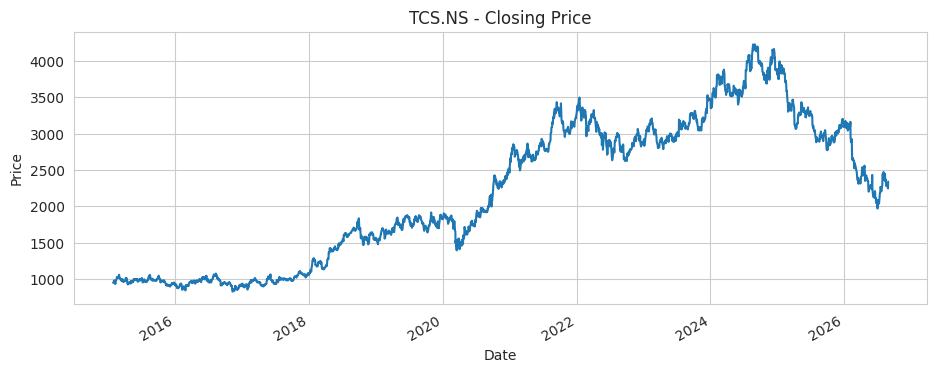

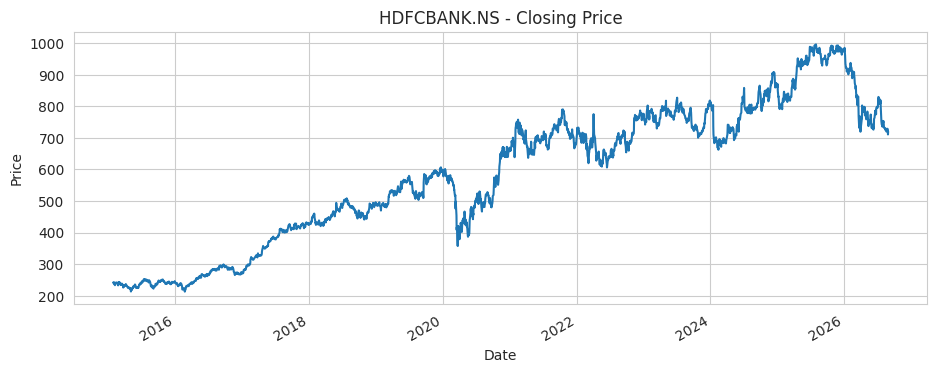

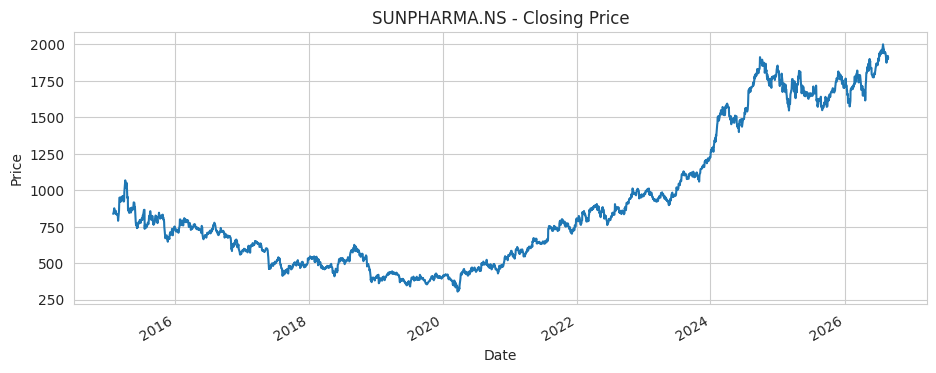

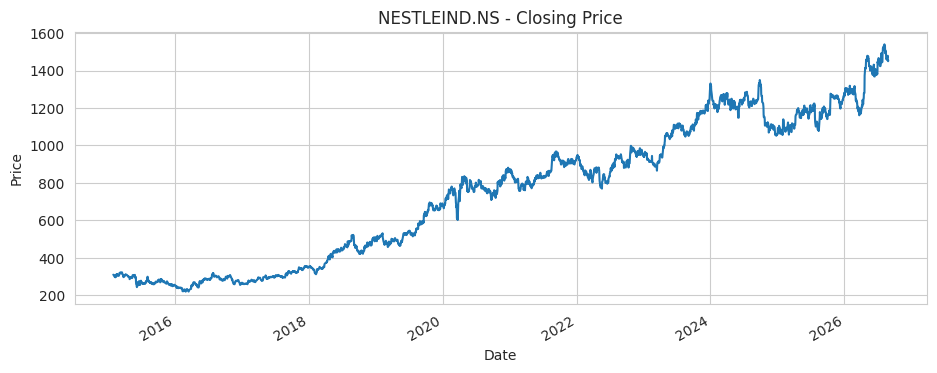

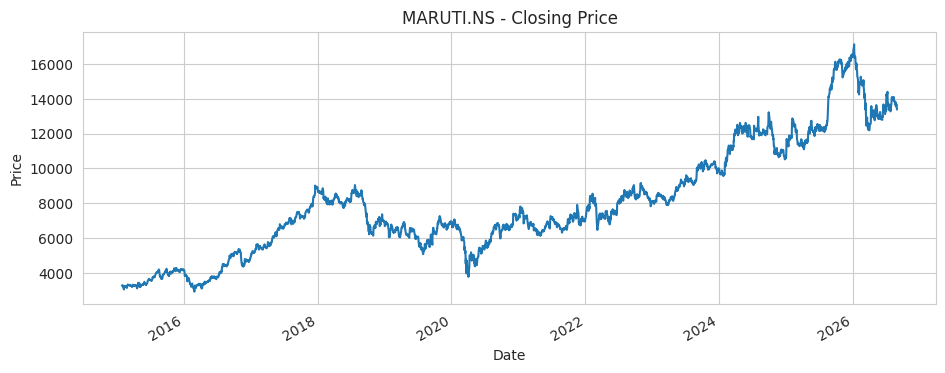

In [6]:
for ticker in STOCKS:
    processed[ticker]["full"]["Close"].plot(title=f"{ticker} - Closing Price")
    plt.ylabel("Price")
    plt.show()


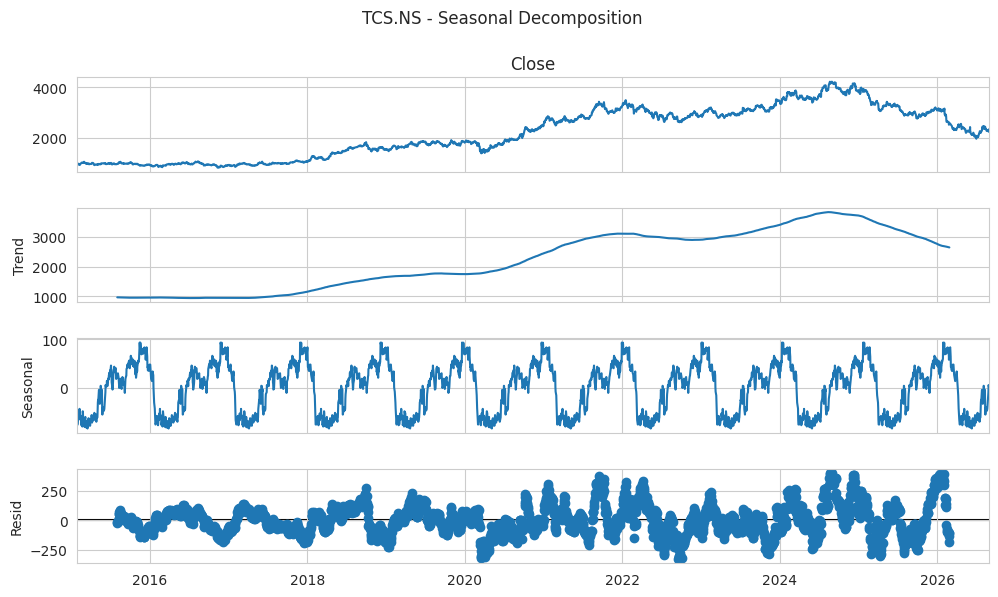

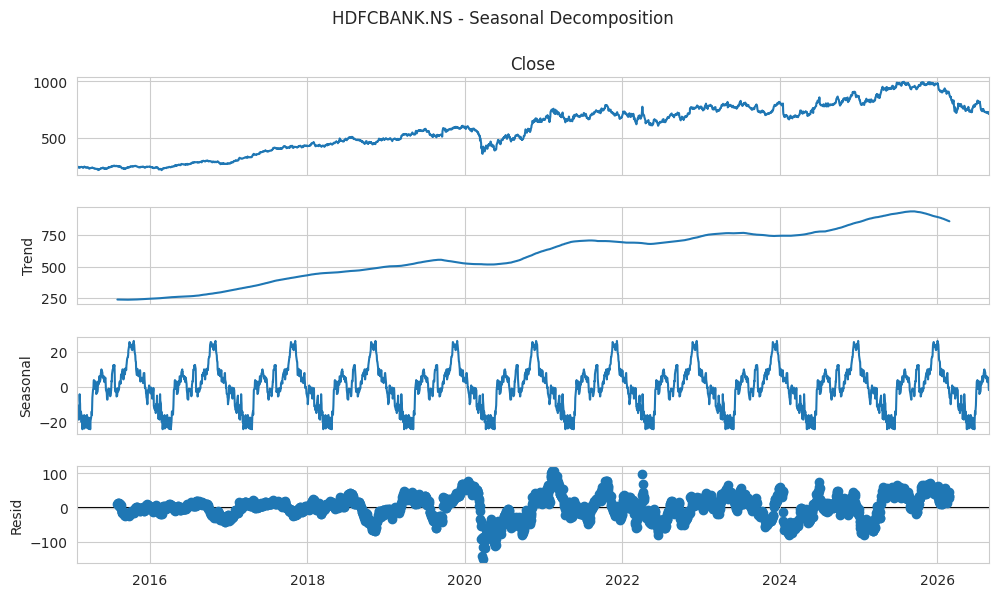

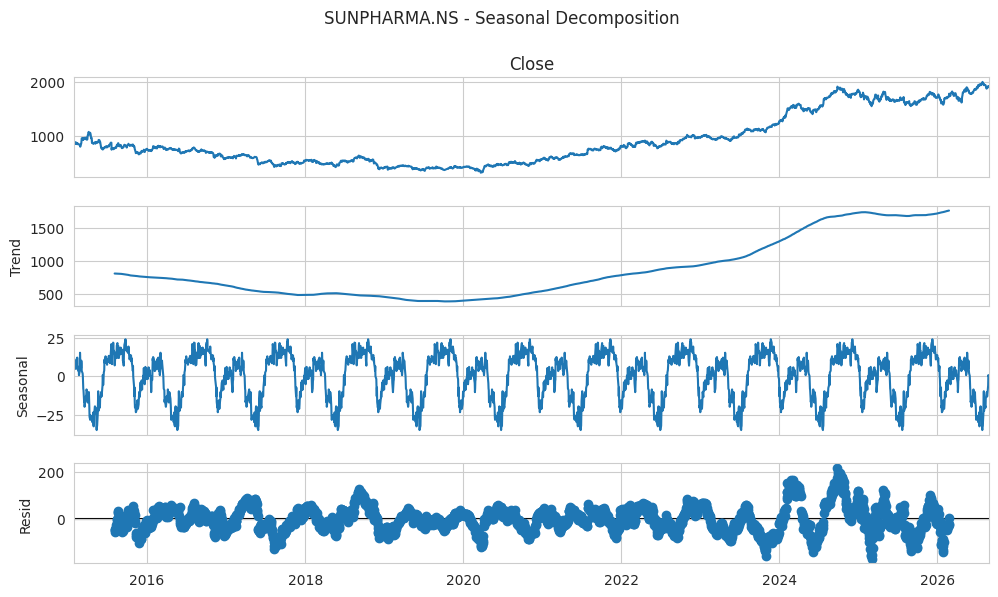

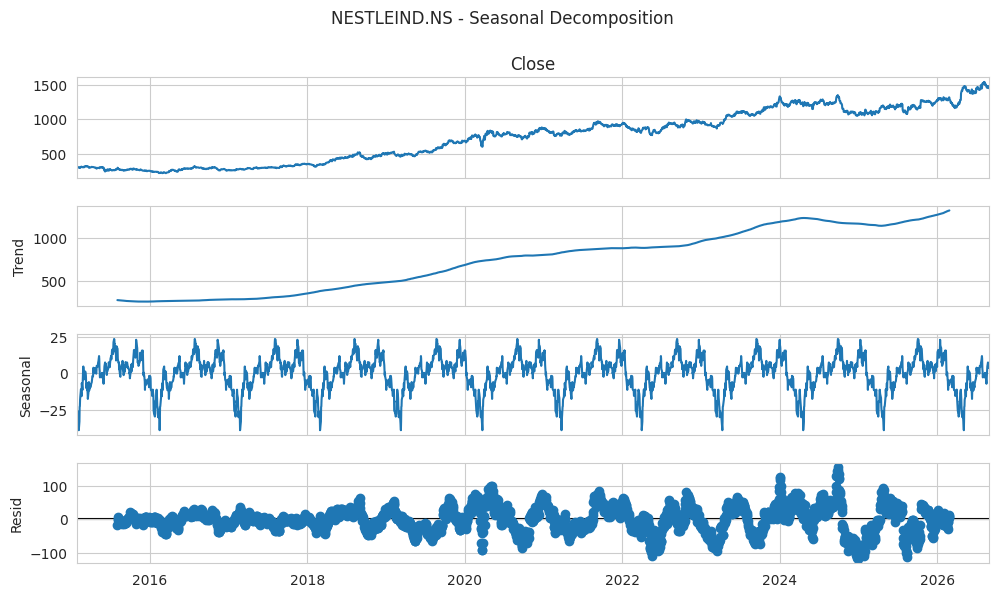

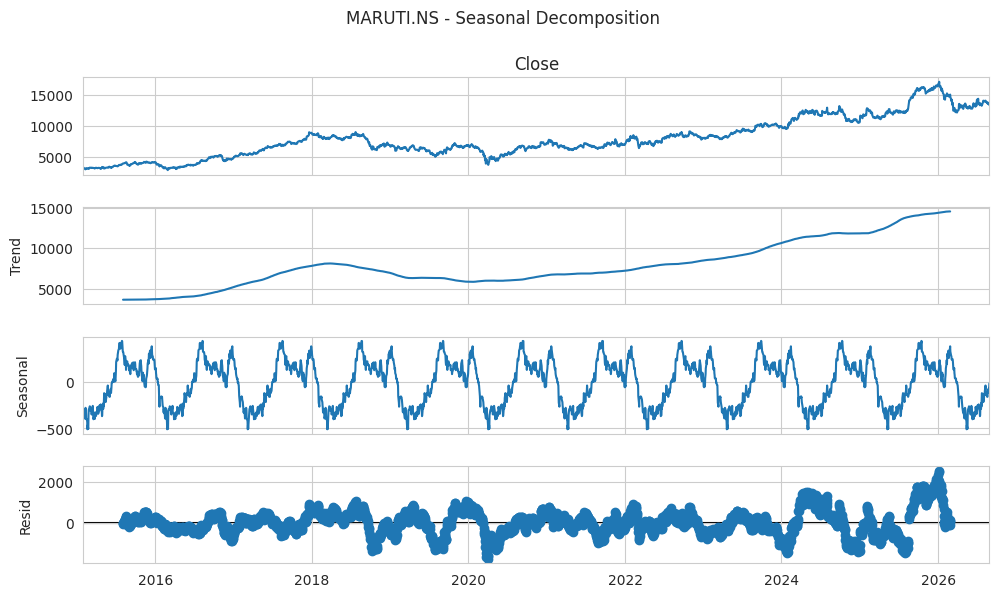

In [7]:
for ticker in STOCKS:
    decomposition = seasonal_decompose(processed[ticker]["full"]["Close"], model="additive", period=252)
    fig = decomposition.plot()
    fig.set_size_inches(10, 6)
    plt.suptitle(f"{ticker} - Seasonal Decomposition", y=1.02)
    plt.show()


In [8]:
volatility_summary = {
    ticker: processed[ticker]["full"]["Rolling_STD"].mean()
    for ticker in STOCKS
}
pd.Series(volatility_summary, name="Avg 20d Rolling Volatility").to_frame()


,Avg 20d Rolling Volatility
TCS.NS,0.014172
HDFCBANK.NS,0.012530
SUNPHARMA.NS,0.016427
NESTLEIND.NS,0.013399
MARUTI.NS,0.015435


## 5. Stationarity Check (ADF Test)

In [9]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    verdict = "Stationary" if result[1] < 0.05 else "Non-Stationary"
    return {"Series": name, "ADF Statistic": result[0], "p-value": result[1], "Verdict": verdict}


adf_rows = []
for ticker in STOCKS:
    adf_rows.append(adf_test(processed[ticker]["full"]["Close"], f"{ticker} - Close"))
    adf_rows.append(adf_test(processed[ticker]["full"]["Log_Returns"], f"{ticker} - Log Returns"))

adf_df = pd.DataFrame(adf_rows)
adf_df


,Series,ADF Statistic,p-value,Verdict
0,TCS.NS - Close,-1.368185,0.597430,Non-Stationary
1,TCS.NS - Log Returns,-54.053403,0.000000,Stationary
2,HDFCBANK.NS - Close,-1.548255,0.509520,Non-Stationary
3,HDFCBANK.NS - Log Returns,-20.098959,0.000000,Stationary
4,SUNPHARMA.NS - Close,0.682291,0.989478,Non-Stationary
5,SUNPHARMA.NS - Log Returns,-53.922027,0.000000,Stationary
6,NESTLEIND.NS - Close,-0.080296,0.951366,Non-Stationary
7,NESTLEIND.NS - Log Returns,-55.364877,0.000000,Stationary
8,MARUTI.NS - Close,-0.973359,0.762856,Non-Stationary
9,MARUTI.NS - Log Returns,-52.606526,0.000000,Stationary


## 6. Classical Statistical Models

### 6.1 ARIMA

In [10]:
def run_arima(train_series, test_series):
    train_series = train_series.astype(float).dropna()
    test_series = test_series.astype(float).dropna()

    auto_model = pm.auto_arima(train_series, seasonal=False, suppress_warnings=True, error_action="ignore")
    order = auto_model.order

    model_fit = ARIMA(train_series, order=order).fit()
    forecast = model_fit.forecast(steps=len(test_series))

    rmse = np.sqrt(mean_squared_error(test_series, forecast))
    mae = mean_absolute_error(test_series, forecast)
    mape = mean_absolute_percentage_error(test_series, forecast) * 100

    return {"order": order, "actual": test_series, "forecast": forecast,
            "test_index": test_series.index, "rmse": rmse, "mae": mae, "mape": mape}


arima_results = {}
for ticker in STOCKS:
    arima_results[ticker] = run_arima(processed[ticker]["train"]["Close"], processed[ticker]["test"]["Close"])
    print(f"{ticker}: order={arima_results[ticker]['order']}  RMSE={arima_results[ticker]['rmse']:.2f}")


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


TCS.NS: order=(0, 1, 0)  RMSE=138.81


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


HDFCBANK.NS: order=(0, 1, 0)  RMSE=44.78


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


SUNPHARMA.NS: order=(5, 2, 0)  RMSE=449.45


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


NESTLEIND.NS: order=(2, 1, 2)  RMSE=83.93
MARUTI.NS: order=(0, 1, 1)  RMSE=806.71


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### 6.2 SARIMAX


In [11]:
def run_sarimax(train_series, test_series, m=5):
    train_series = train_series.astype(float).dropna()
    test_series = test_series.astype(float).dropna()

    auto_model = pm.auto_arima(
        train_series, seasonal=True, m=m,
        max_p=2, max_q=2, max_P=1, max_Q=1,
        suppress_warnings=True, error_action="ignore",
    )
    order, seasonal_order = auto_model.order, auto_model.seasonal_order

    model_fit = SARIMAX(
        train_series, order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False)
    forecast = model_fit.forecast(steps=len(test_series))

    rmse = np.sqrt(mean_squared_error(test_series, forecast))
    mae = mean_absolute_error(test_series, forecast)
    mape = mean_absolute_percentage_error(test_series, forecast) * 100

    return {"order": order, "seasonal_order": seasonal_order, "actual": test_series, "forecast": forecast,
            "test_index": test_series.index, "rmse": rmse, "mae": mae, "mape": mape}


sarimax_results = {}
for ticker in STOCKS:
    sarimax_results[ticker] = run_sarimax(processed[ticker]["train"]["Close"], processed[ticker]["test"]["Close"])
    print(f"{ticker}: order={sarimax_results[ticker]['order']}, "
          f"seasonal={sarimax_results[ticker]['seasonal_order']}  RMSE={sarimax_results[ticker]['rmse']:.2f}")


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


TCS.NS: order=(0, 1, 0), seasonal=(0, 0, 0, 5)  RMSE=138.81


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


HDFCBANK.NS: order=(2, 1, 2), seasonal=(1, 0, 0, 5)  RMSE=44.30


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


SUNPHARMA.NS: order=(2, 2, 0), seasonal=(1, 0, 1, 5)  RMSE=349.72


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


NESTLEIND.NS: order=(2, 1, 2), seasonal=(0, 0, 0, 5)  RMSE=84.01
MARUTI.NS: order=(0, 1, 1), seasonal=(0, 0, 0, 5)  RMSE=806.71


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


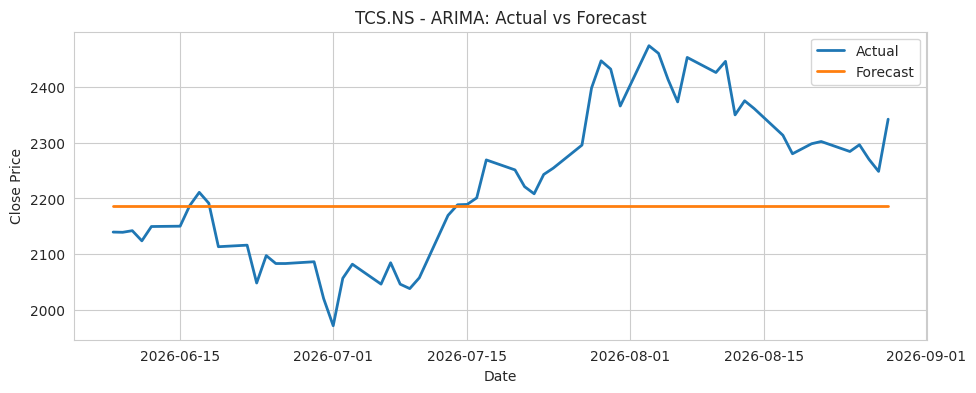

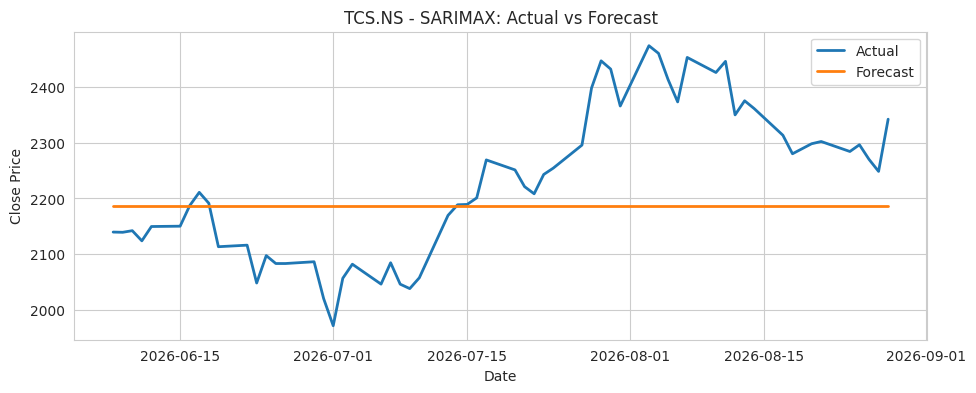

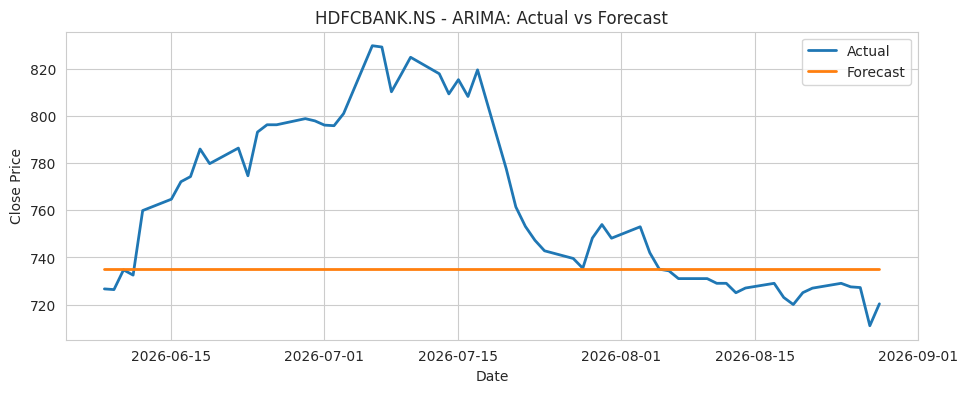

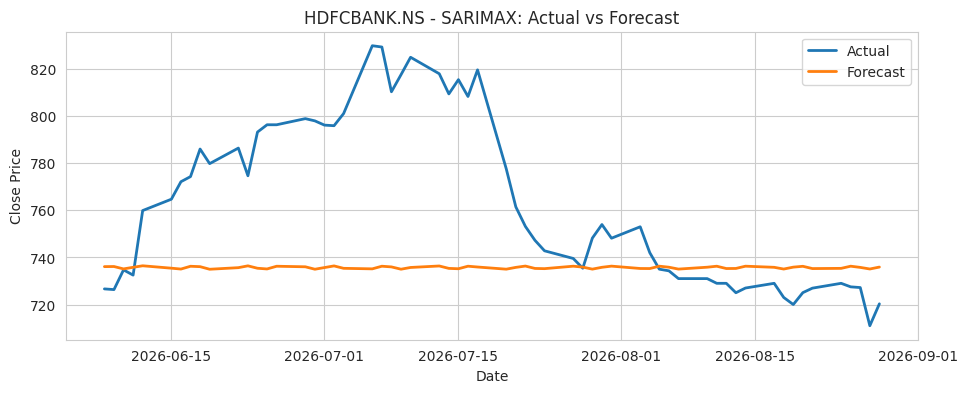

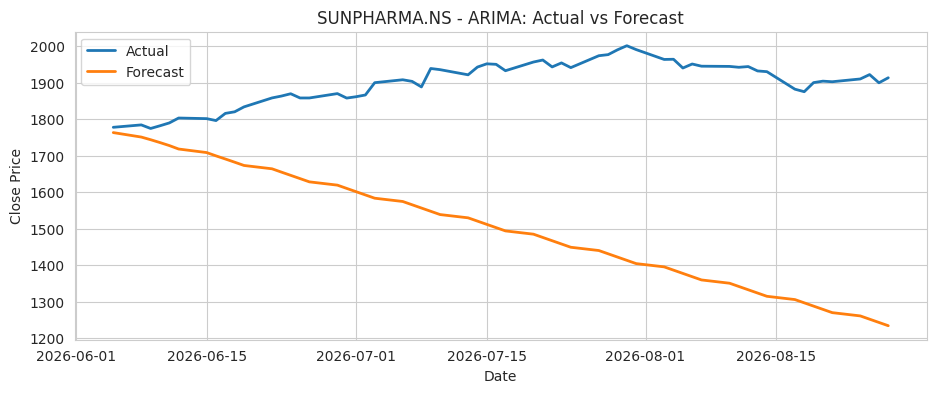

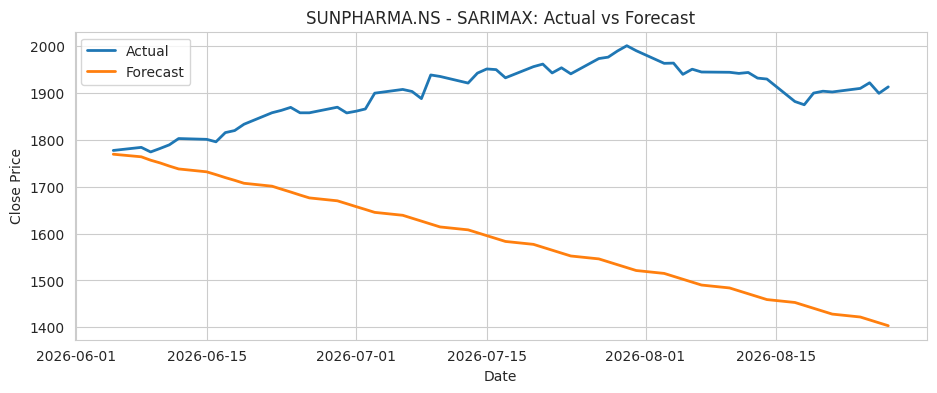

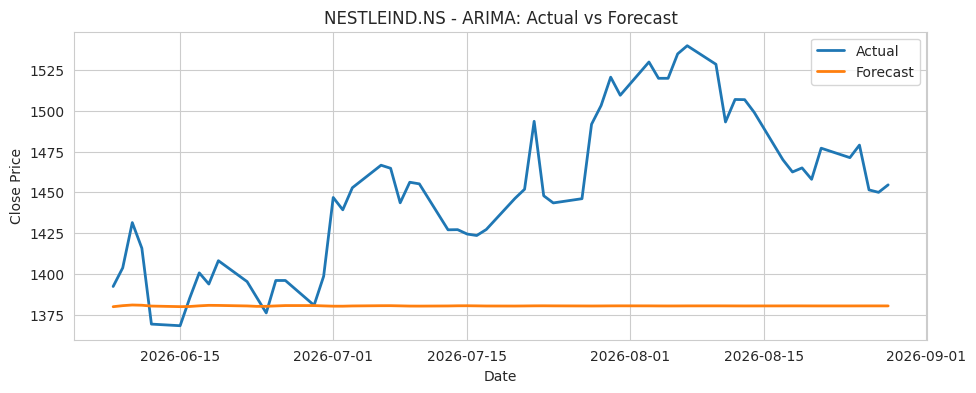

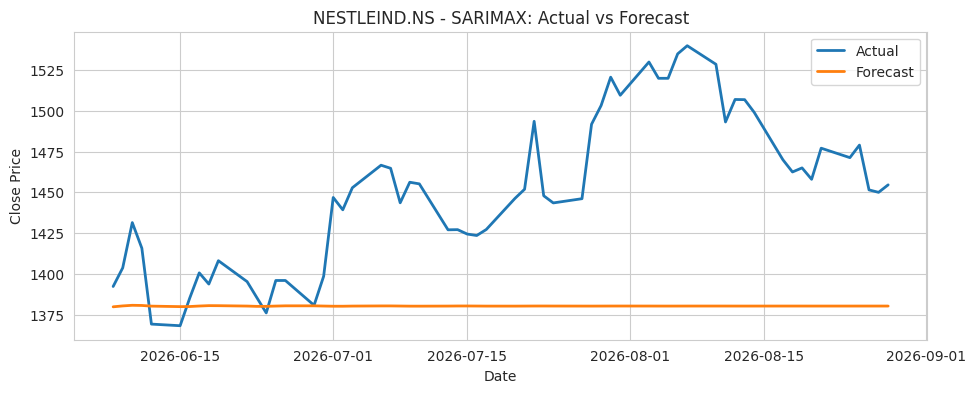

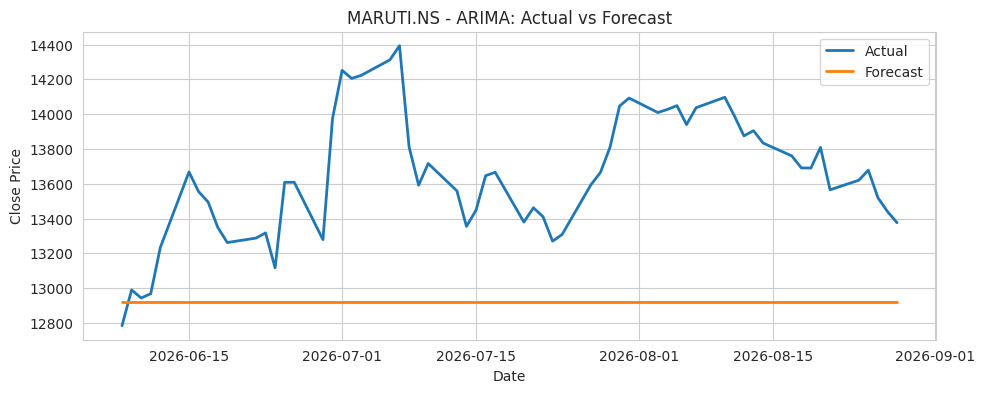

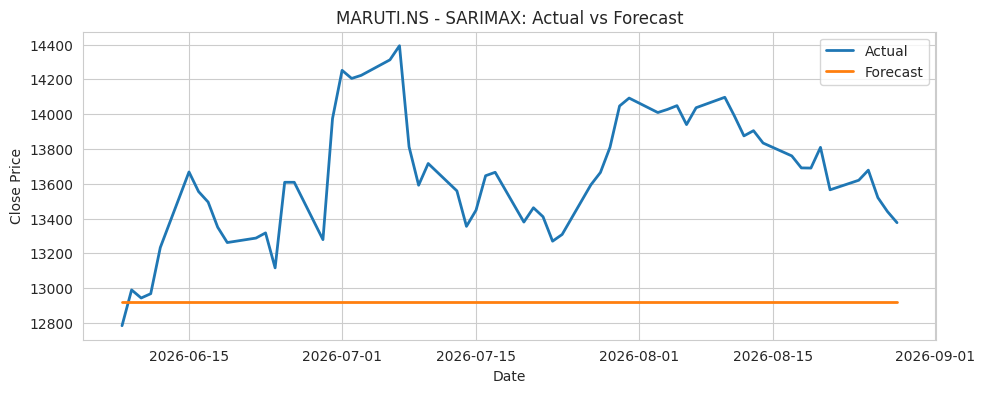

In [12]:
def plot_forecast(result, ticker, model_name):
    plt.plot(result["test_index"], result["actual"], label="Actual", linewidth=2)
    plt.plot(result["test_index"], result["forecast"], label="Forecast", linewidth=2)
    plt.title(f"{ticker} - {model_name}: Actual vs Forecast")
    plt.xlabel("Date"); plt.ylabel("Close Price")
    plt.legend(); plt.show()


for ticker in STOCKS:
    plot_forecast(arima_results[ticker], ticker, "ARIMA")
    plot_forecast(sarimax_results[ticker], ticker, "SARIMAX")


## 7. Volatility Forecasting: GARCH

ARIMA, SARIMAX, and the deep learning models all forecast *price*. None of them forecast *risk*. A simple
**GARCH(1,1)** model does exactly that: it looks at how volatile a stock has been recently and forecasts how
volatile it's likely to be over the next `TEST_SIZE` days. This forecast is used later, in the portfolio
section, to decide how much money to put into each stock (safer stocks get a bigger share).

In [13]:
def run_garch(train_log_returns, test_len):
    ret_pct = train_log_returns.dropna() * 100     # GARCH works better on a percent scale
    am = arch_model(ret_pct, vol="Garch", p=1, q=1, dist="normal", mean="Zero")
    res = am.fit(disp="off")

    forecast = res.forecast(horizon=test_len, reindex=False)
    daily_vol_forecast = np.sqrt(forecast.variance.values[-1]) / 100
    annual_vol_forecast = daily_vol_forecast[-1] * np.sqrt(252)

    return {"model": res, "annual_vol_forecast": annual_vol_forecast}


garch_results = {}
garch_rows = []
for ticker in STOCKS:
    garch_results[ticker] = run_garch(processed[ticker]["train"]["Log_Returns"], TEST_SIZE)
    realized_annual_vol = processed[ticker]["test"]["Log_Returns"].std() * np.sqrt(252)
    garch_rows.append({
        "Stock": ticker,
        "GARCH_Forecast_Annual_Vol": garch_results[ticker]["annual_vol_forecast"],
        "Realized_Annual_Vol": realized_annual_vol,
    })
    print(f"{ticker}: GARCH forecast vol={garch_results[ticker]['annual_vol_forecast']:.1%}  "
          f"realized vol={realized_annual_vol:.1%}")

garch_df = pd.DataFrame(garch_rows).set_index("Stock")
garch_df


TCS.NS: GARCH forecast vol=23.7%  realized vol=32.6%
HDFCBANK.NS: GARCH forecast vol=21.5%  realized vol=21.2%
SUNPHARMA.NS: GARCH forecast vol=24.1%  realized vol=13.3%
NESTLEIND.NS: GARCH forecast vol=22.1%  realized vol=20.8%
MARUTI.NS: GARCH forecast vol=25.7%  realized vol=23.1%


,GARCH_Forecast_Annual_Vol,Realized_Annual_Vol
Stock,,
TCS.NS,0.237070,0.326126
HDFCBANK.NS,0.215051,0.212475
SUNPHARMA.NS,0.241457,0.133152
NESTLEIND.NS,0.221499,0.207613
MARUTI.NS,0.256782,0.231241


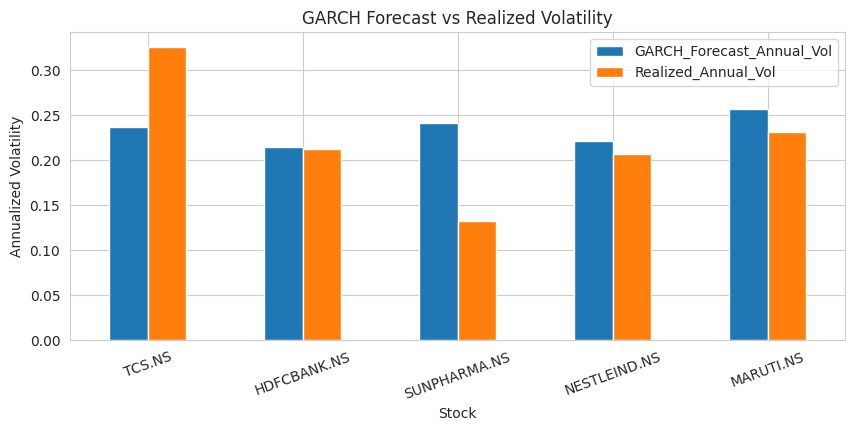

In [14]:
garch_df.plot(kind="bar", figsize=(10, 4), title="GARCH Forecast vs Realized Volatility")
plt.ylabel("Annualized Volatility")
plt.xticks(rotation=20)
plt.show()


## 8. Deep Learning Models: LSTM vs GRU vs Transformer


### 8.1 Turning the data into windows the models can learn from

In [15]:
def create_sequences(feature_arr, target_arr, window):
    """Turns a table of daily features into (past `window` days -> next day's return) examples.
    feature_arr: (n_days, n_features) already-scaled feature matrix.
    target_arr:  (n_days,) already-scaled target (next-day return)."""
    X, y = [], []
    for i in range(window, len(feature_arr)):
        X.append(feature_arr[i - window:i])
        y.append(target_arr[i])
    return np.array(X), np.array(y)


### 8.2 Model architectures

In [16]:
def transformer_block(x, head_size=16, num_heads=2, ff_dim=32, dropout=0.3):
    """One Transformer encoder block: self-attention followed by a small feed-forward layer,
    each with a residual connection (standard 'Attention is All You Need' design, kept small
    on purpose since we only have ~2,900 rows of data per stock)."""
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(x.shape[-1])(ff)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ff)
    return x


def build_model(model_type, window, n_features, dropout=0.2):
    inputs = keras.Input(shape=(window, n_features))

    if model_type == "LSTM":
        x = layers.LSTM(64, return_sequences=True)(inputs)
        x = layers.Dropout(dropout)(x)
        x = layers.LSTM(32)(x)
        x = layers.Dense(16, activation="relu")(x)
        optimizer = keras.optimizers.Adam(1e-3)

    elif model_type == "GRU":
        x = layers.GRU(64, return_sequences=True)(inputs)
        x = layers.Dropout(dropout)(x)
        x = layers.GRU(32)(x)
        x = layers.Dense(16, activation="relu")(x)
        optimizer = keras.optimizers.Adam(1e-3)

    elif model_type == "Transformer":
        d_model = 24
        x = layers.Dense(d_model)(inputs)
        positions = tf.range(start=0, limit=window, delta=1)
        pos_embedding = layers.Embedding(input_dim=window, output_dim=d_model)(positions)
        x = x + pos_embedding
        x = transformer_block(x, dropout=0.3)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(16, activation="relu")(x)
        x = layers.Dropout(0.3)(x)

        try:
            optimizer = keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4)
        except AttributeError:
            optimizer = keras.optimizers.Adam(5e-4)

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    outputs = layers.Dense(1)(x)
    model = keras.Model(inputs, outputs, name=model_type)
    model.compile(optimizer=optimizer, loss="mse")
    return model


### 8.3 Train + evaluate, one model at a time, per stock

In [17]:
def train_evaluate_model(model_type, train_df, test_df, window=WINDOW, epochs=EPOCHS, batch_size=BATCH_SIZE,
                          val_fraction=0.1):
    full_df = pd.concat([train_df, test_df])

    # scale the 5 input features using only the training data
    feat_scaler = MinMaxScaler()
    feat_scaler.fit(train_df[FEATURE_COLS])
    full_features_scaled = feat_scaler.transform(full_df[FEATURE_COLS])

    # standardize the target (next-day return) using only the training data
    target_scaler = StandardScaler()
    target_scaler.fit(train_df[[TARGET_COL]])
    full_target_scaled = target_scaler.transform(full_df[[TARGET_COL]]).flatten()

    n_train = len(train_df)
    X_all, y_all = create_sequences(full_features_scaled[:n_train], full_target_scaled[:n_train], window)

    # hold out the last slice of the training windows to watch for overfitting
    n_val = max(1, int(len(X_all) * val_fraction))
    X_train, y_train = X_all[:-n_val], y_all[:-n_val]
    X_val, y_val = X_all[-n_val:], y_all[-n_val:]

    model = build_model(model_type, window, n_features=len(FEATURE_COLS))
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    ]
    history = model.fit(
        X_train, y_train, validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size, verbose=0, callbacks=callbacks,
    )

    # walk-forward evaluation: each test-day prediction uses the true preceding window (no lookahead)
    test_start = n_train
    X_test = np.array([full_features_scaled[i - window:i] for i in range(test_start, len(full_features_scaled))])
    pred_target_scaled = model.predict(X_test, verbose=0).flatten()
    pred_return = target_scaler.inverse_transform(pred_target_scaled.reshape(-1, 1)).flatten()

    # turn the predicted % return back into a predicted PRICE: price[t] = price[t-1] * exp(return[t])
    prev_close = full_df["Close"].values[test_start - 1: len(full_df) - 1]
    forecast = prev_close * np.exp(pred_return)
    actual = test_df["Close"].values

    return {
        "model": model, "history": history,
        "feat_scaler": feat_scaler, "target_scaler": target_scaler,
        "pred_return": pred_return,
        "actual": actual, "forecast": forecast, "test_index": test_df.index,
        "rmse": float(np.sqrt(mean_squared_error(actual, forecast))),
        "mae": float(mean_absolute_error(actual, forecast)),
        "mape": float(mean_absolute_percentage_error(actual, forecast) * 100),
    }


In [18]:
MODEL_TYPES = ["LSTM", "GRU", "Transformer"]
dl_results = {ticker: {} for ticker in STOCKS}

# Run one model at a time, across all 5 stocks, before moving to the next model.
for model_type in MODEL_TYPES:
    print(f"\n========== {model_type} ==========")
    for ticker in STOCKS:
        dl_results[ticker][model_type] = train_evaluate_model(
            model_type, processed[ticker]["train"], processed[ticker]["test"]
        )
        r = dl_results[ticker][model_type]
        print(f"{ticker:15s}  RMSE={r['rmse']:.2f}  MAE={r['mae']:.2f}  MAPE={r['mape']:.2f}%")



========== LSTM ==========
TCS.NS           RMSE=45.55  MAE=34.87  MAPE=1.56%
HDFCBANK.NS      RMSE=10.36  MAE=7.09  MAPE=0.92%


SUNPHARMA.NS     RMSE=15.98  MAE=11.94  MAPE=0.63%
NESTLEIND.NS     RMSE=18.79  MAE=14.11  MAPE=0.97%
MARUTI.NS        RMSE=196.69  MAE=140.16  MAPE=1.03%

========== GRU ==========
TCS.NS           RMSE=45.56  MAE=34.86  MAPE=1.56%
HDFCBANK.NS      RMSE=10.36  MAE=7.08  MAPE=0.92%
SUNPHARMA.NS     RMSE=15.99  MAE=11.95  MAPE=0.63%
NESTLEIND.NS     RMSE=18.76  MAE=14.13  MAPE=0.98%
MARUTI.NS        RMSE=196.81  MAE=140.50  MAPE=1.03%

========== Transformer ==========
TCS.NS           RMSE=45.58  MAE=34.86  MAPE=1.56%
HDFCBANK.NS      RMSE=10.36  MAE=7.06  MAPE=0.92%
SUNPHARMA.NS     RMSE=16.00  MAE=11.97  MAPE=0.63%
NESTLEIND.NS     RMSE=18.79  MAE=14.15  MAPE=0.98%
MARUTI.NS        RMSE=196.69  MAE=140.21  MAPE=1.03%


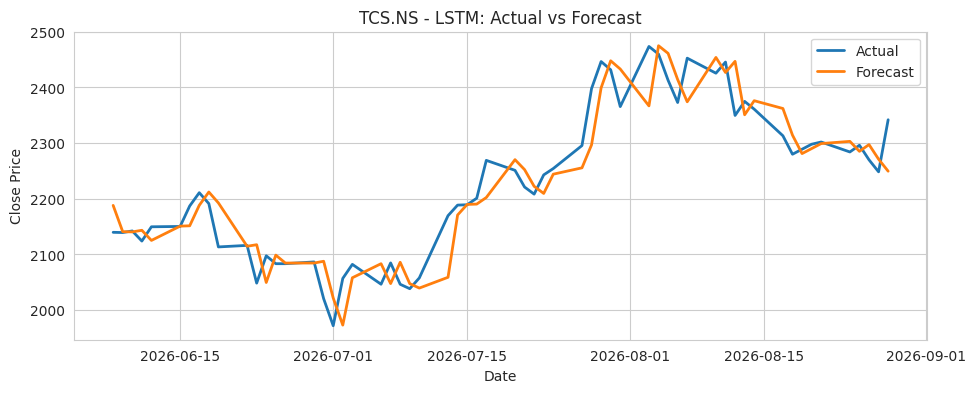

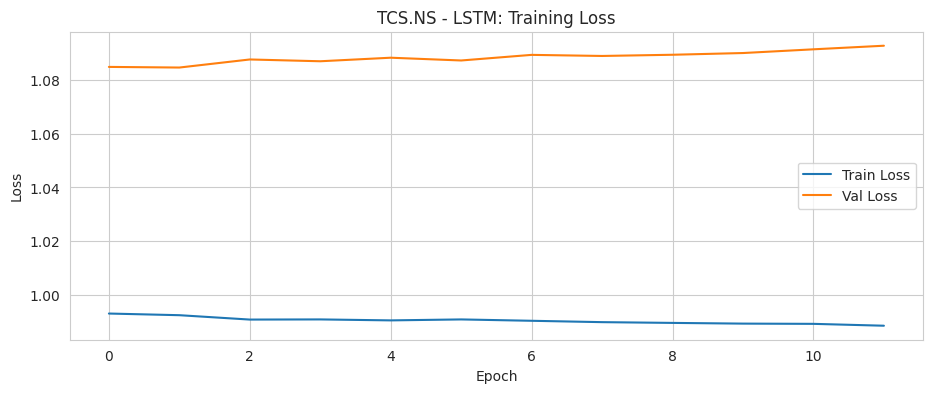

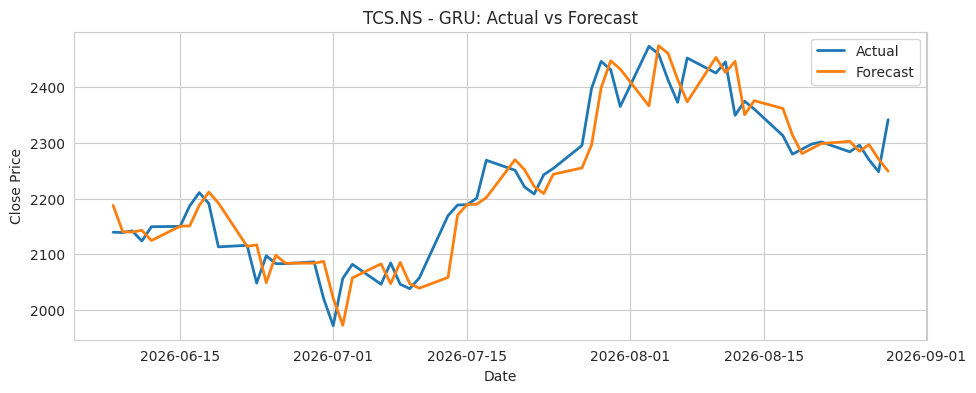

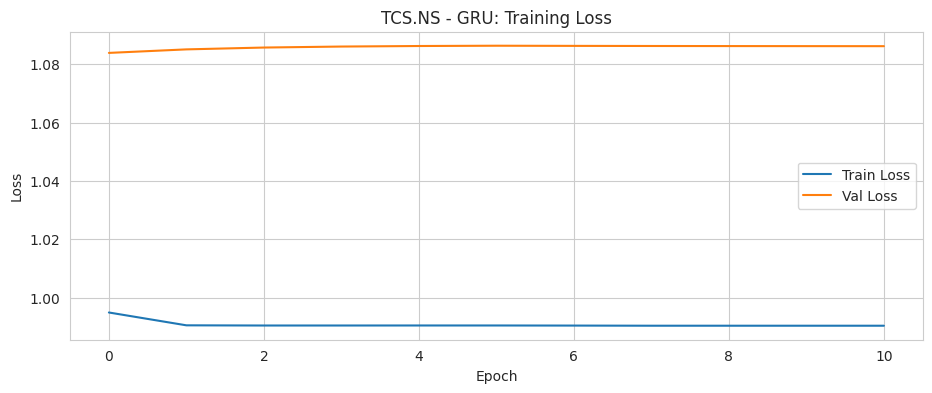

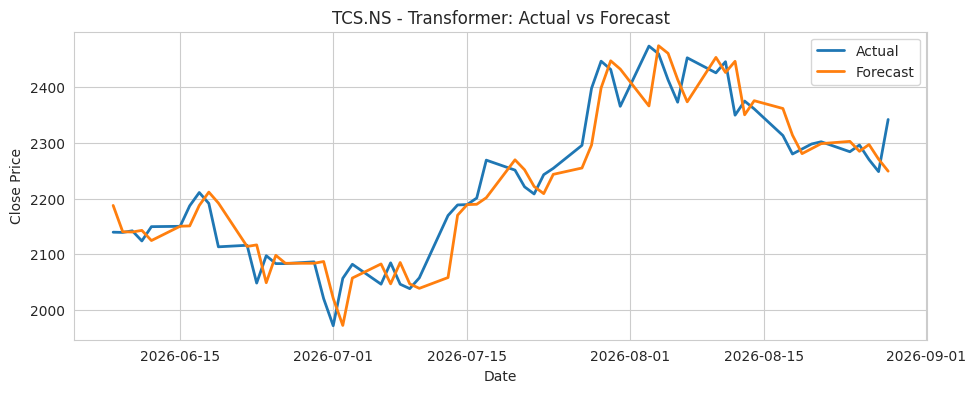

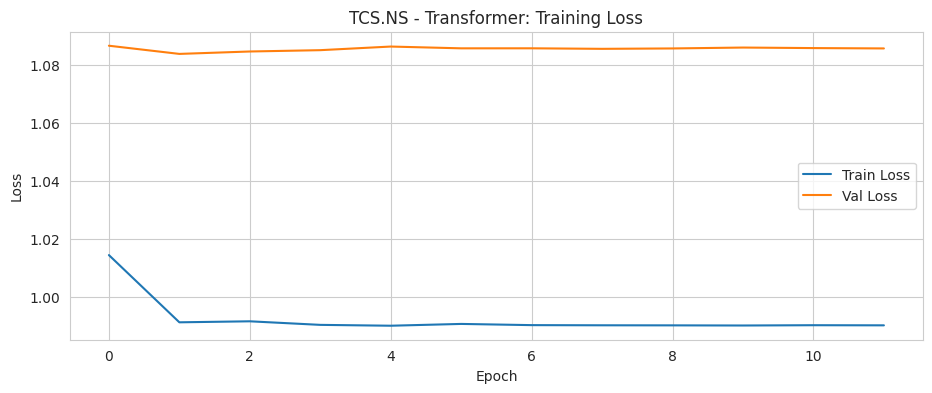

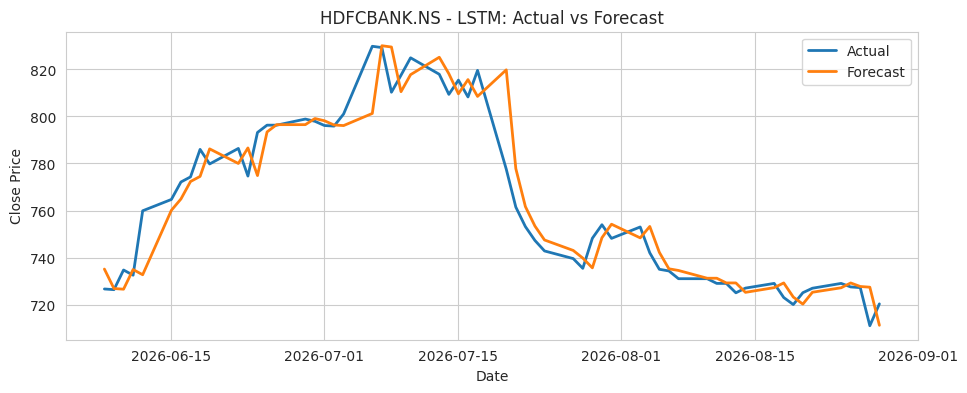

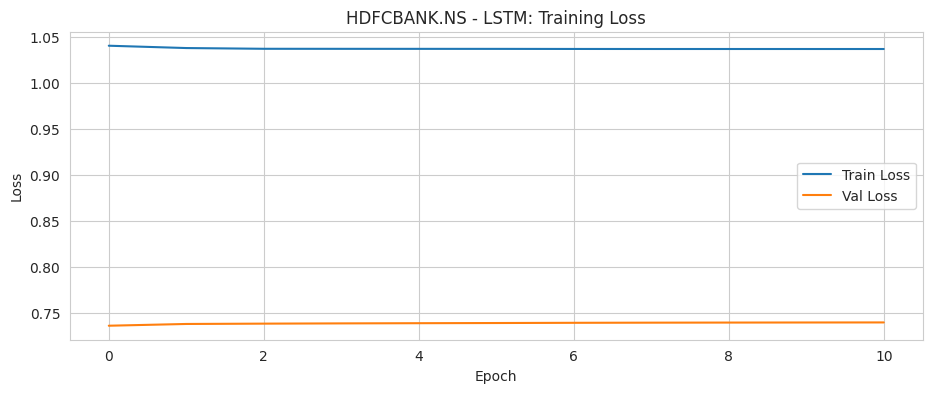

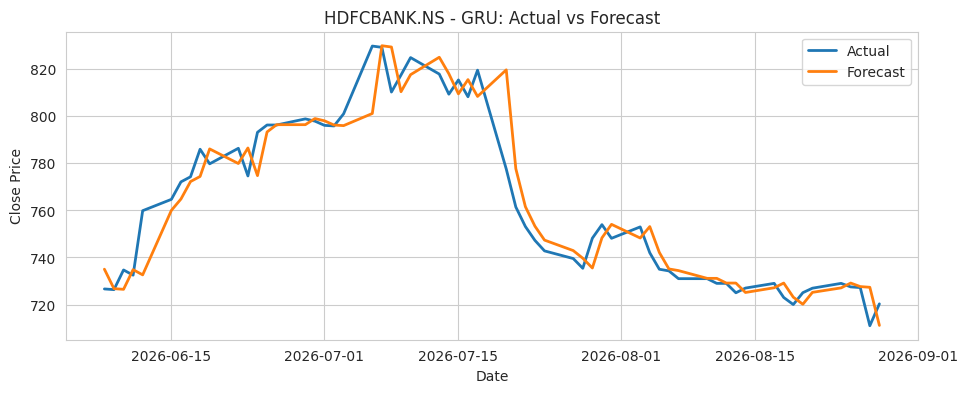

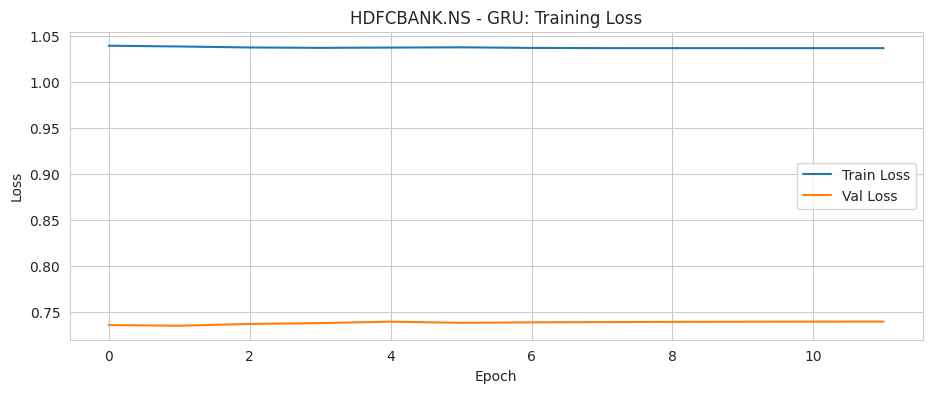

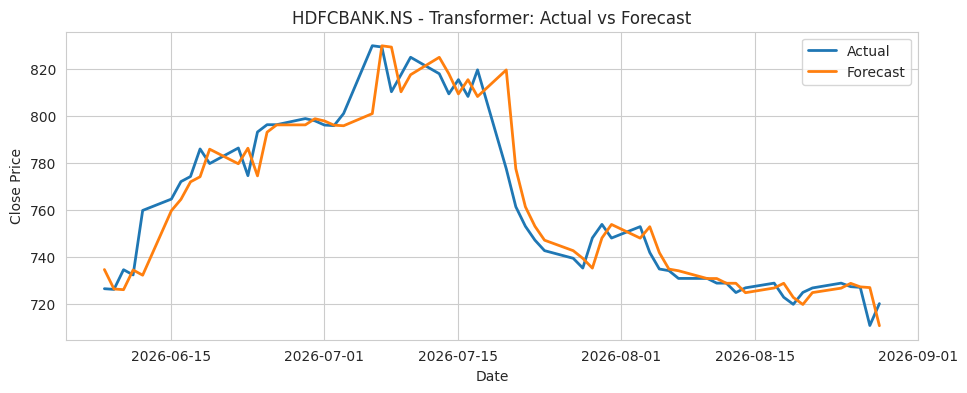

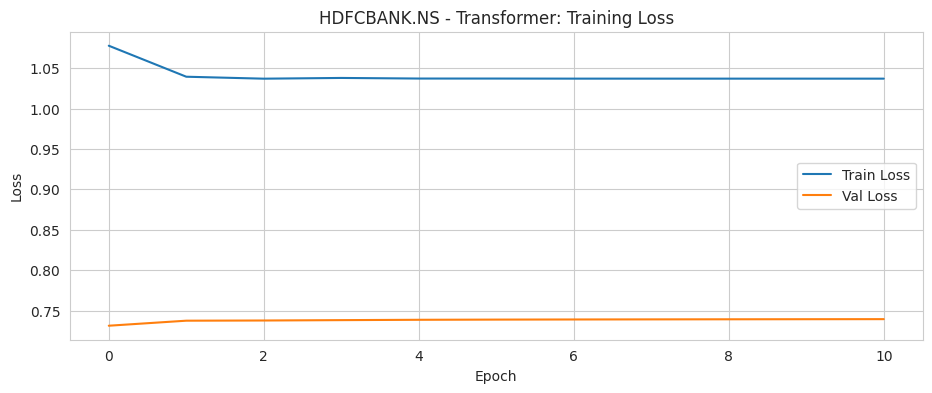

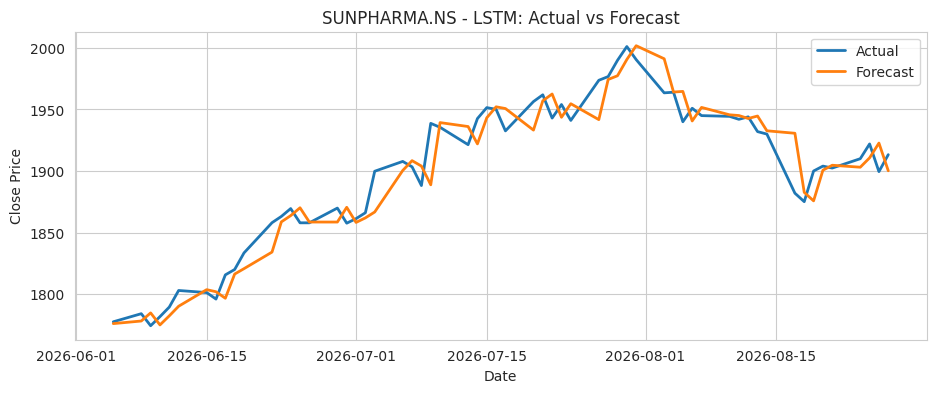

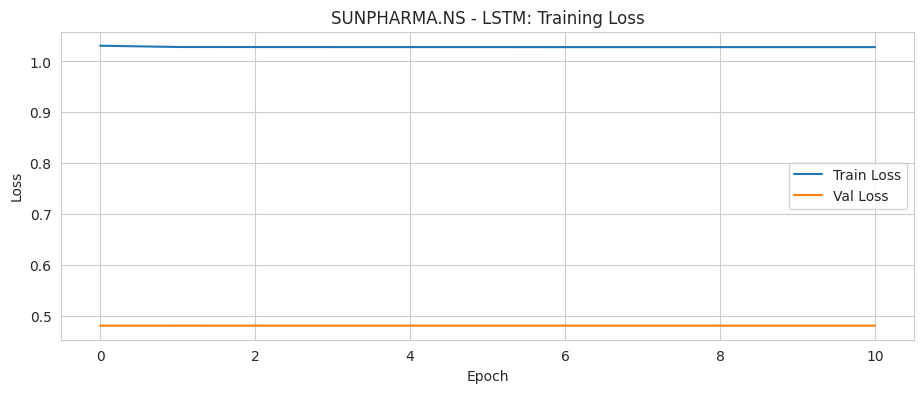

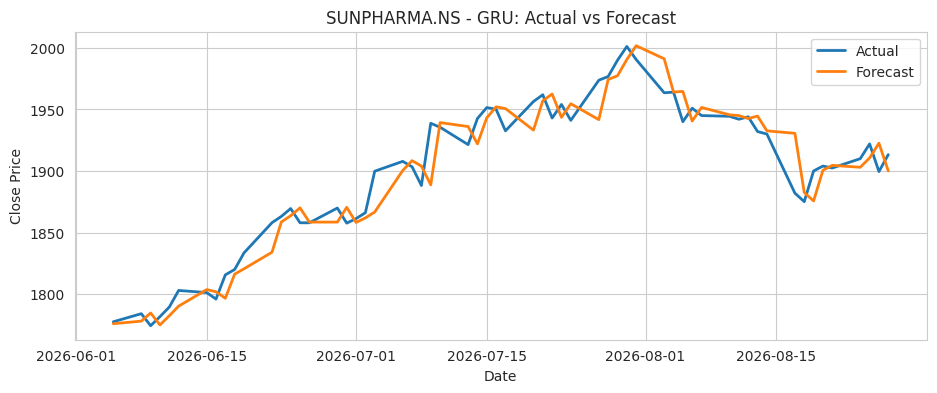

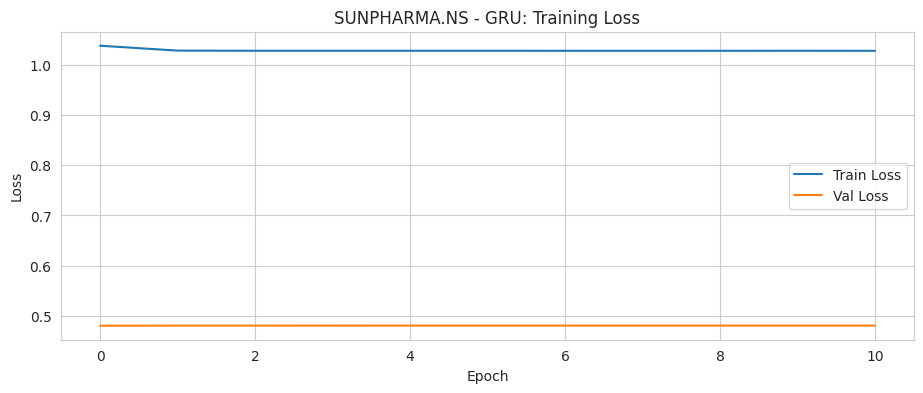

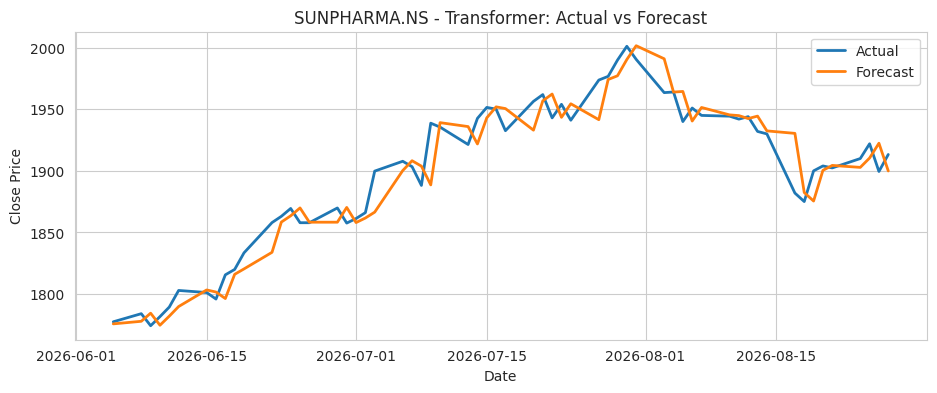

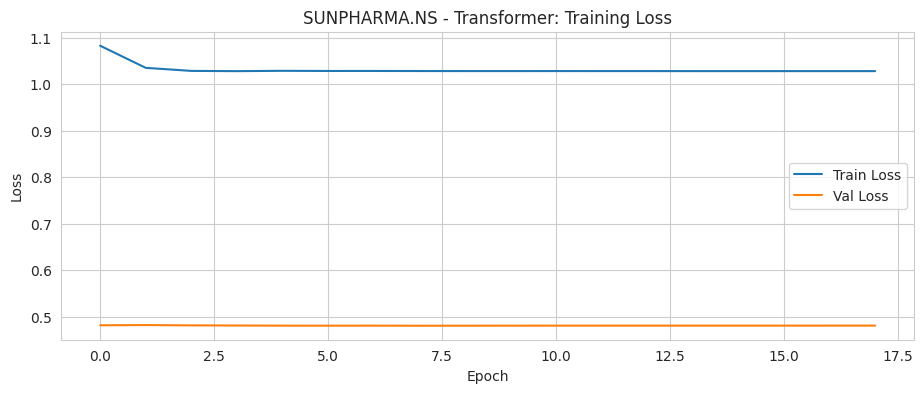

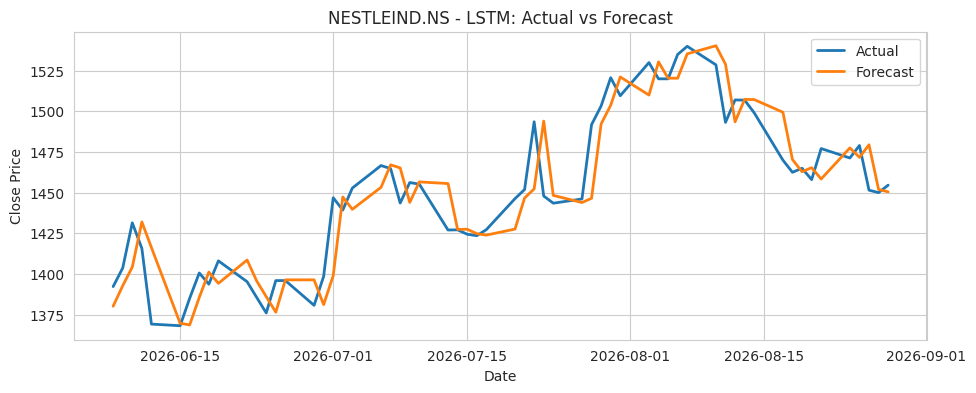

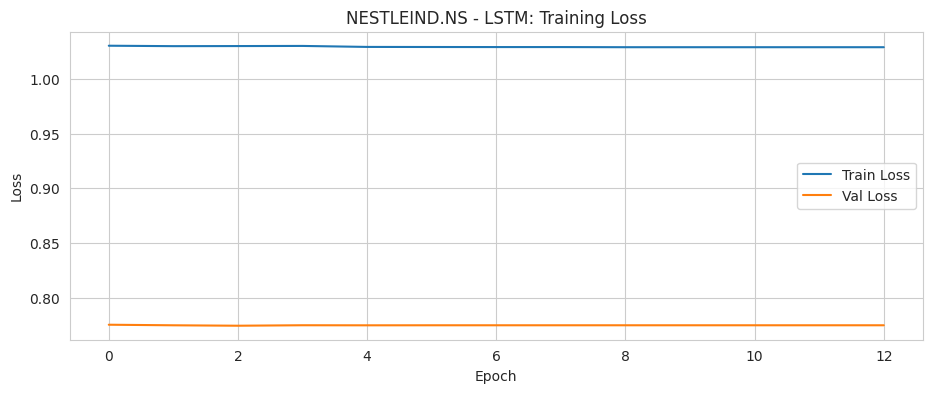

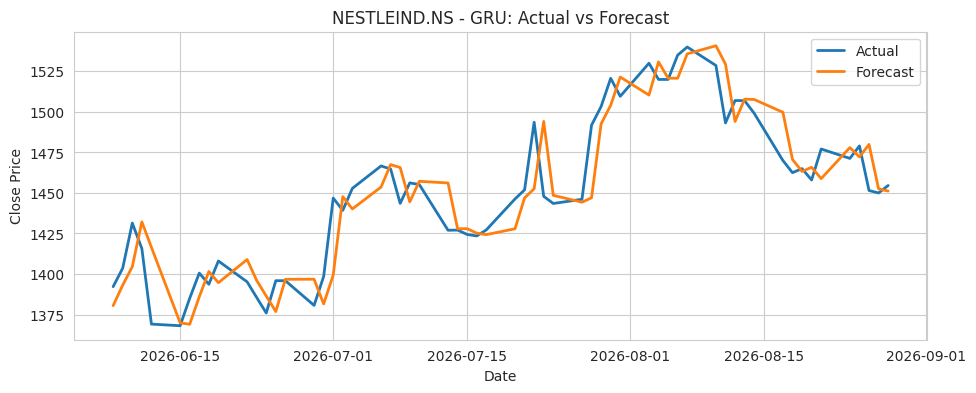

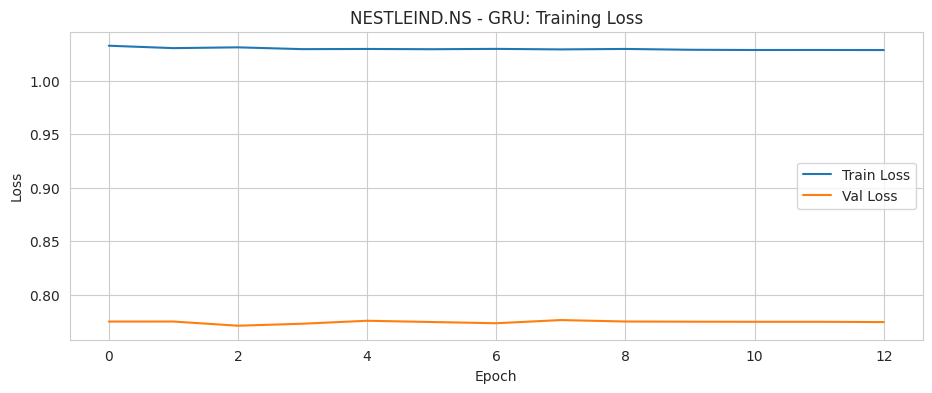

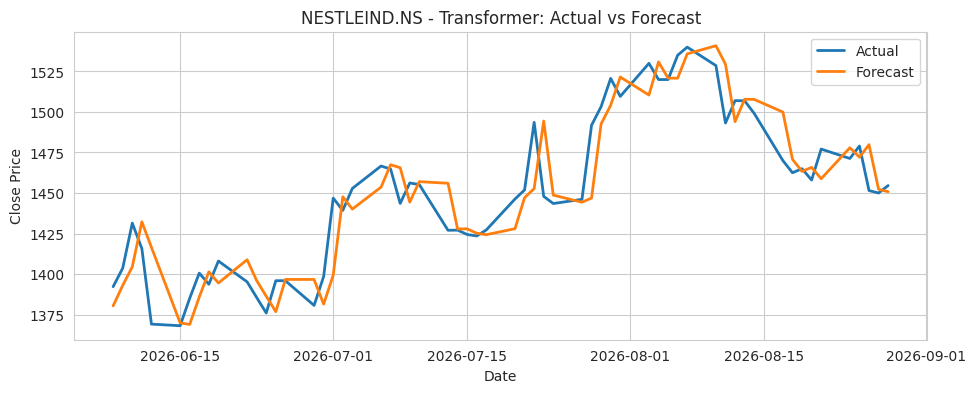

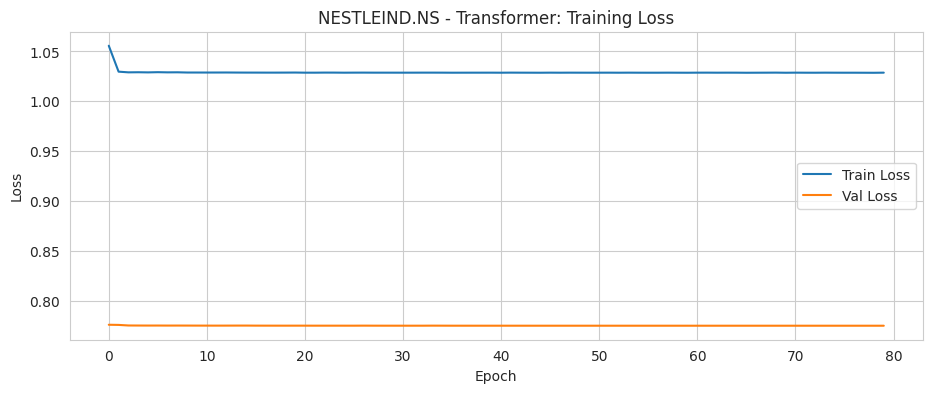

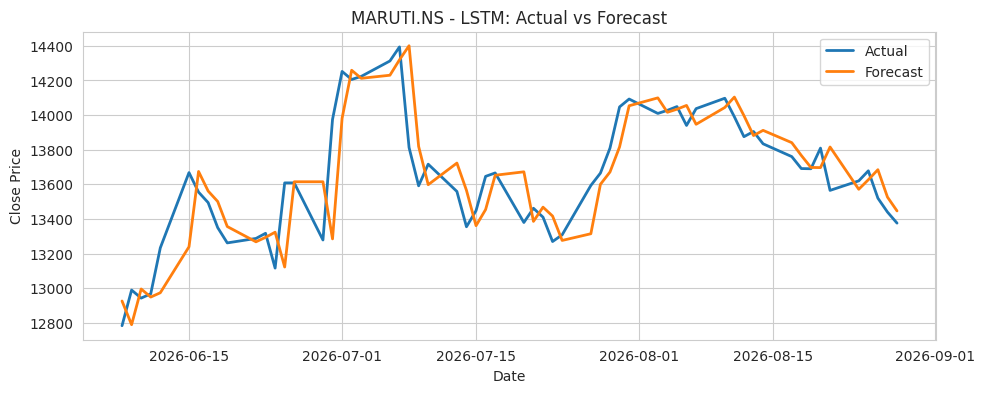

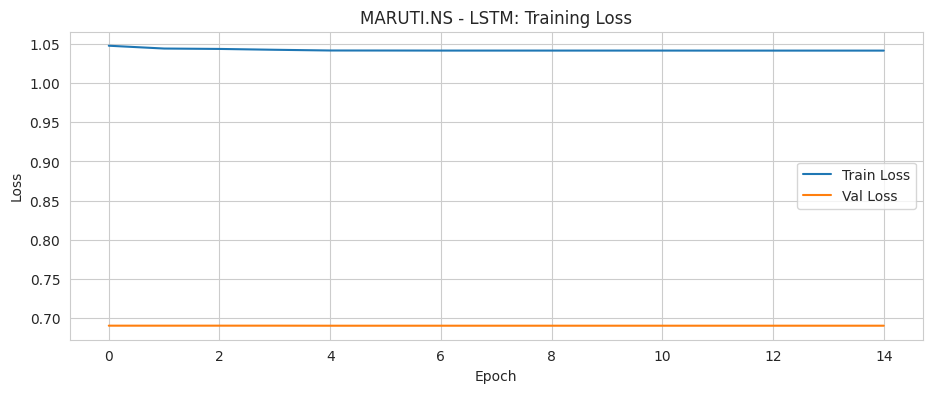

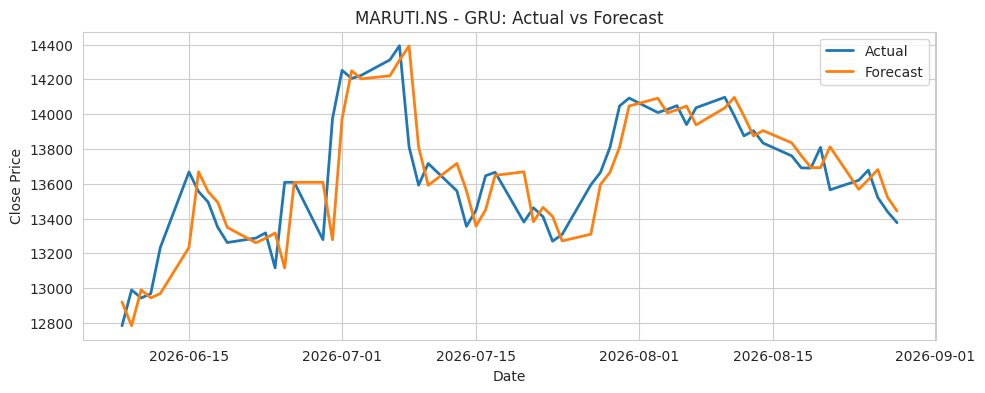

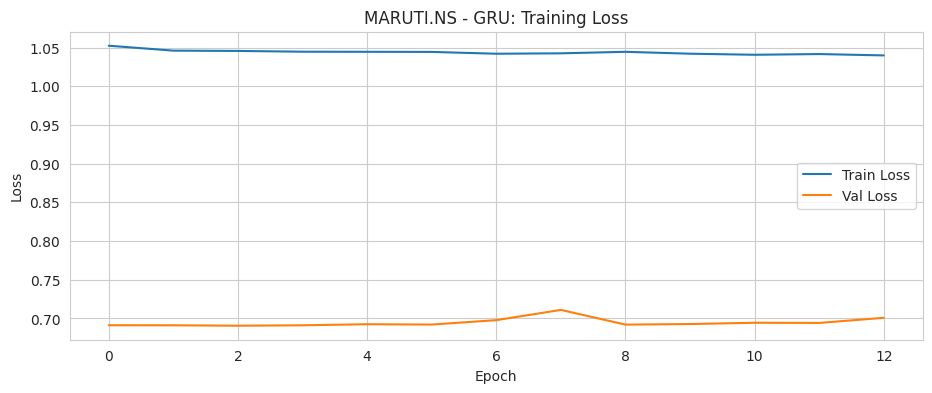

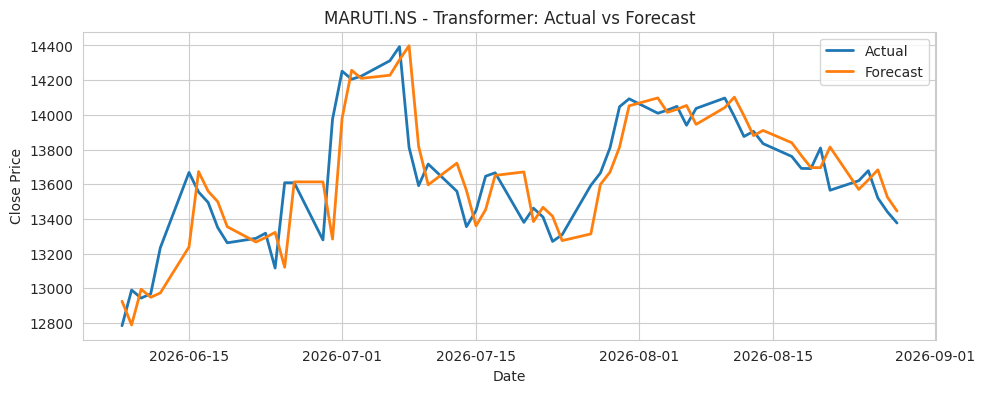

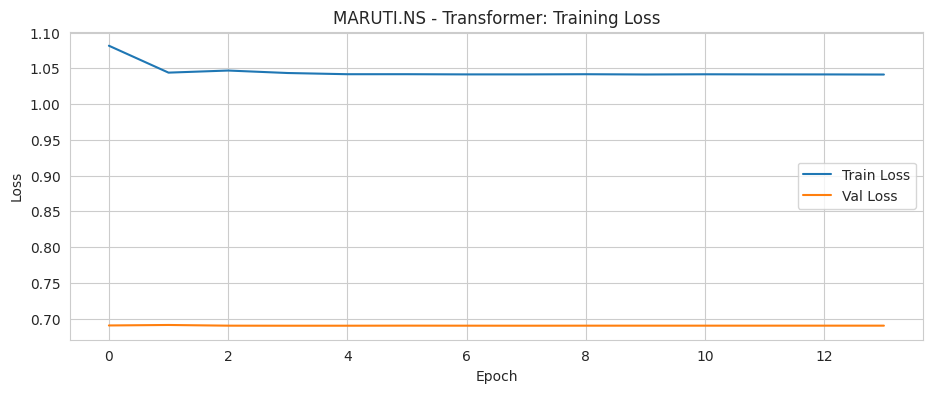

In [19]:
def plot_dl_results(result, ticker, model_type):
    plt.plot(result["test_index"], result["actual"], label="Actual", linewidth=2)
    plt.plot(result["test_index"], result["forecast"], label="Forecast", linewidth=2)
    plt.title(f"{ticker} - {model_type}: Actual vs Forecast")
    plt.xlabel("Date"); plt.ylabel("Close Price")
    plt.legend(); plt.show()


def plot_training_loss(result, ticker, model_type):
    h = result["history"].history
    plt.plot(h["loss"], label="Train Loss")
    if "val_loss" in h:
        plt.plot(h["val_loss"], label="Val Loss")
    plt.title(f"{ticker} - {model_type}: Training Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.show()


for ticker in STOCKS:
    for model_type in MODEL_TYPES:
        plot_dl_results(dl_results[ticker][model_type], ticker, model_type)
        plot_training_loss(dl_results[ticker][model_type], ticker, model_type)


## 9. Model Comparison

In [20]:
comparison_rows = []
for ticker in STOCKS:
    row = {
        "Stock": ticker,
        "Naive_RMSE": np.nan,
        "ARIMA_RMSE": arima_results[ticker]["rmse"],
        "SARIMAX_RMSE": sarimax_results[ticker]["rmse"],
    }

    test = processed[ticker]["test"]
    train = processed[ticker]["train"]
    naive_prev = np.concatenate([[train["Close"].iloc[-1]], test["Close"].values[:-1]])
    row["Naive_RMSE"] = float(np.sqrt(mean_squared_error(test["Close"].values, naive_prev)))

    for model_type in MODEL_TYPES:
        row[f"{model_type}_RMSE"] = dl_results[ticker][model_type]["rmse"]
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("Stock")

model_cols = [c for c in comparison_df.columns if c.endswith("_RMSE")]
comparison_df["Best_Model"] = comparison_df[model_cols].idxmin(axis=1).str.replace("_RMSE", "", regex=False)
for model in ["ARIMA", "SARIMAX"] + MODEL_TYPES:
    comparison_df[f"{model}_Improvement_vs_Naive_%"] = (
        (comparison_df["Naive_RMSE"] - comparison_df[f"{model}_RMSE"])
        / comparison_df["Naive_RMSE"] * 100
    )

comparison_df


,Naive_RMSE,ARIMA_RMSE,SARIMAX_RMSE,LSTM_RMSE,GRU_RMSE,Transformer_RMSE,Best_Model,ARIMA_Improvement_vs_Naive_%,SARIMAX_Improvement_vs_Naive_%,LSTM_Improvement_vs_Naive_%,GRU_Improvement_vs_Naive_%,Transformer_Improvement_vs_Naive_%
Stock,,,,,,,,,,,,
TCS.NS,45.599076,138.813124,138.813124,45.554813,45.564201,45.582033,LSTM,-204.420917,-204.420917,0.097068,0.076482,0.037375
HDFCBANK.NS,10.352035,44.781959,44.299618,10.361508,10.356739,10.359383,Naive,-332.590889,-327.931499,-0.091506,-0.045444,-0.070982
SUNPHARMA.NS,16.057490,449.451645,349.720866,15.981348,15.985039,16.004961,LSTM,-2699.015634,-2077.929892,0.474182,0.451192,0.327130
NESTLEIND.NS,18.818602,83.934773,84.011376,18.790211,18.760362,18.789031,GRU,-346.020234,-346.427296,0.150869,0.309481,0.157138
MARUTI.NS,196.776991,806.711315,806.711608,196.689251,196.814892,196.690838,LSTM,-309.962218,-309.962366,0.044588,-0.019261,0.043782


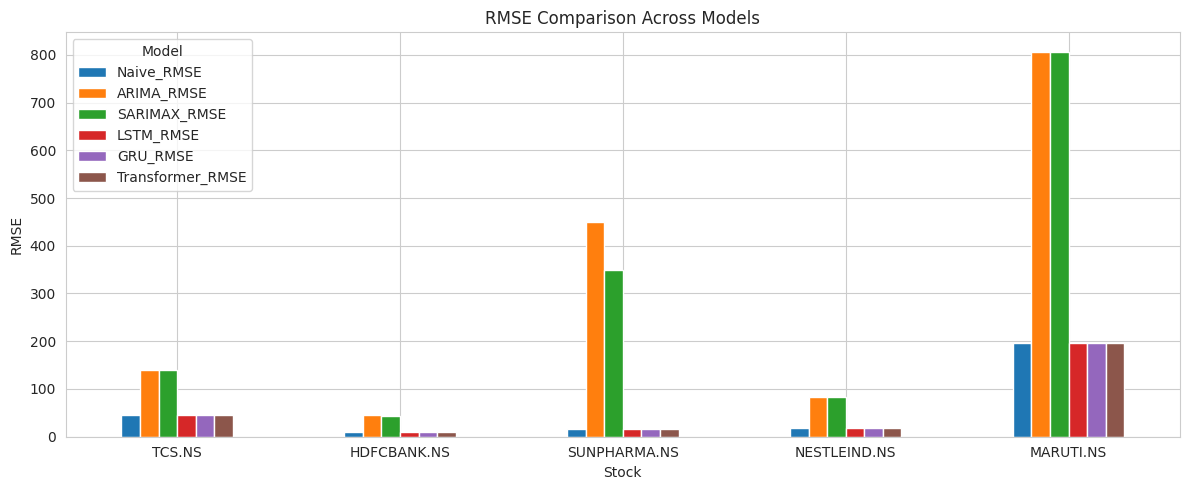

In [21]:
rmse_cols = [c for c in comparison_df.columns if c.endswith("_RMSE")]
comparison_df[rmse_cols].plot(kind="bar", figsize=(12, 5))
plt.title("RMSE Comparison Across Models")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


In [22]:
avg_naive_rmse = comparison_df["Naive_RMSE"].mean()
avg_arima_rmse = comparison_df["ARIMA_RMSE"].mean()
avg_best_dl_rmse = comparison_df[[f"{m}_RMSE" for m in MODEL_TYPES]].min(axis=1).mean()

# Percentage improvement computed per stock first, then averaged, so a high-priced
# stock cannot dominate the summary.
best_dl_improvement = (
    (comparison_df["Naive_RMSE"] -
     comparison_df[[f"{m}_RMSE" for m in MODEL_TYPES]].min(axis=1))
    / comparison_df["Naive_RMSE"] * 100
).mean()

print(f"Average naive RMSE:             {avg_naive_rmse:.2f}")
print(f"Average ARIMA RMSE:             {avg_arima_rmse:.2f}")
print(f"Average best deep-learning RMSE: {avg_best_dl_rmse:.2f}")
print(f"Mean per-stock improvement of best DL vs naive: {best_dl_improvement:.1f}%")
print()
print("Best model per stock:")
print(comparison_df["Best_Model"])


Average naive RMSE:             57.52
Average ARIMA RMSE:             304.74
Average best deep-learning RMSE: 57.47
Mean per-stock improvement of best DL vs naive: 0.2%

Best model per stock:
Stock
TCS.NS           LSTM
HDFCBANK.NS     Naive
SUNPHARMA.NS     LSTM
NESTLEIND.NS      GRU
MARUTI.NS        LSTM
Name: Best_Model, dtype: object


## 10. Backtesting the Trading Signals

The v1 notebook generated **one** signal per stock, right at the end, using a fixed ±2% threshold — and
every stock came back "HOLD", because a 1-day forecast almost never moves 2%.

v2 fixes this two ways:

1. **A signal for every day of the test period**, not just the last one — we already have a day-by-day
   forecast from Section 8.
2. **A threshold based on each stock's own volatility**, instead of one fixed number for every stock. A
   calm stock like HDFCBANK and a volatile one like MARUTI shouldn't use the same ±2% bar.

For each stock: go **long** the day after a BUY signal, stay **flat** otherwise (no short-selling), and
compare the result to simply buying and holding.

In [23]:
TRANSACTION_COST_BPS = 5
MAX_POSITION = 1.0
VOL_TARGET = 0.01

def backtest_stock(ticker, model_type):
    result = dl_results[ticker][model_type]

    predicted_return = np.asarray(result["pred_return"], dtype=float)
    actual_close = np.asarray(result["actual"], dtype=float)

    # Previous close for each test day.
    prev_close = np.concatenate([
        [processed[ticker]["train"]["Close"].iloc[-1]],
        actual_close[:-1]
    ])
    actual_daily_return = actual_close / prev_close - 1.0

    # Volatility estimate is based only on training observations.
    train_daily_vol = float(processed[ticker]["train"]["Log_Returns"].std())

    raw_position = np.maximum(predicted_return, 0.0) / max(VOL_TARGET, 1e-8)
    positions = np.clip(raw_position, 0.0, MAX_POSITION)

    # Transaction costs are charged on changes in position.
    turnover = np.abs(np.diff(np.r_[0.0, positions]))
    costs = turnover * (TRANSACTION_COST_BPS / 10000.0)

    strategy_return = positions * actual_daily_return - costs

    equity = np.cumprod(1.0 + strategy_return)
    buyhold_equity = np.cumprod(1.0 + actual_daily_return)

    daily_std = strategy_return.std(ddof=1)
    sharpe_ratio = (
        strategy_return.mean() / daily_std * np.sqrt(252)
        if daily_std > 0 else 0.0
    )

    running_max = np.maximum.accumulate(equity)
    max_drawdown = np.min(equity / running_max - 1.0)

    return {
        "ticker": ticker,
        "model": model_type,
        "train_daily_vol": train_daily_vol,
        "equity_curve": equity,
        "buyhold_curve": buyhold_equity,
        "test_index": result["test_index"],
        "sharpe_ratio": float(sharpe_ratio),
        "max_drawdown": float(max_drawdown),
        "strategy_return_%": float((equity[-1] - 1) * 100),
        "buyhold_return_%": float((buyhold_equity[-1] - 1) * 100),
        "days_with_position": int(np.sum(positions > 0)),
        "avg_position": float(np.mean(positions)),
    }


backtest_results = {}
backtest_rows = []

for ticker in STOCKS:
    best_model = comparison_df.loc[ticker, "Best_Model"]
    if best_model not in MODEL_TYPES:
        best_model = min(MODEL_TYPES, key=lambda m: dl_results[ticker][m]["rmse"])

    bt = backtest_stock(ticker, best_model)
    backtest_results[ticker] = bt

    backtest_rows.append({
        "Stock": ticker,
        "Model": best_model,
        "Strategy_Return_%": bt["strategy_return_%"],
        "BuyHold_Return_%": bt["buyhold_return_%"],
        "Sharpe_Ratio": bt["sharpe_ratio"],
        "Max_Drawdown_%": bt["max_drawdown"] * 100,
        "Days_With_Position": bt["days_with_position"],
        "Avg_Position": bt["avg_position"],
    })

backtest_df = pd.DataFrame(backtest_rows).set_index("Stock")
backtest_df


,Model,Strategy_Return_%,BuyHold_Return_%,Sharpe_Ratio,Max_Drawdown_%,Days_With_Position,Avg_Position
Stock,,,,,,,
TCS.NS,LSTM,0.448826,7.091781,1.051823,-0.636274,60,0.054529
HDFCBANK.NS,GRU,-0.026553,-1.986027,-0.299802,-0.264648,60,0.017523
SUNPHARMA.NS,LSTM,0.266238,7.764420,2.467719,-0.219999,60,0.034413
NESTLEIND.NS,GRU,0.472874,5.438775,1.691356,-0.300121,60,0.058104
MARUTI.NS,LSTM,0.190520,3.527479,0.730518,-0.377209,60,0.047396


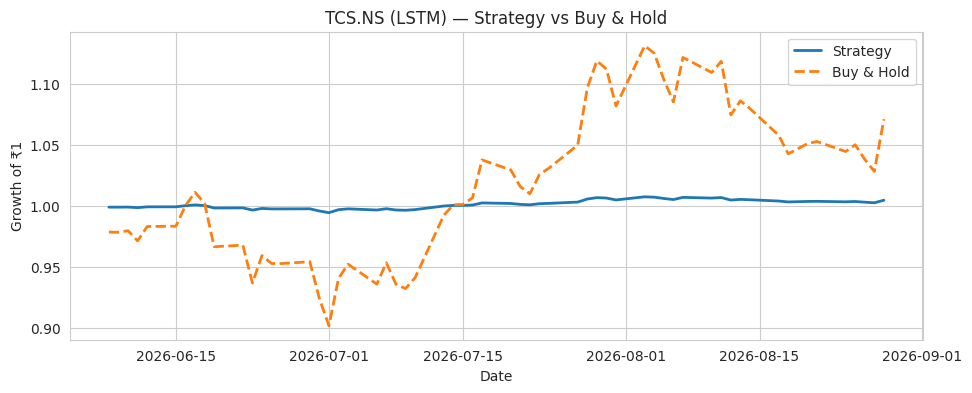

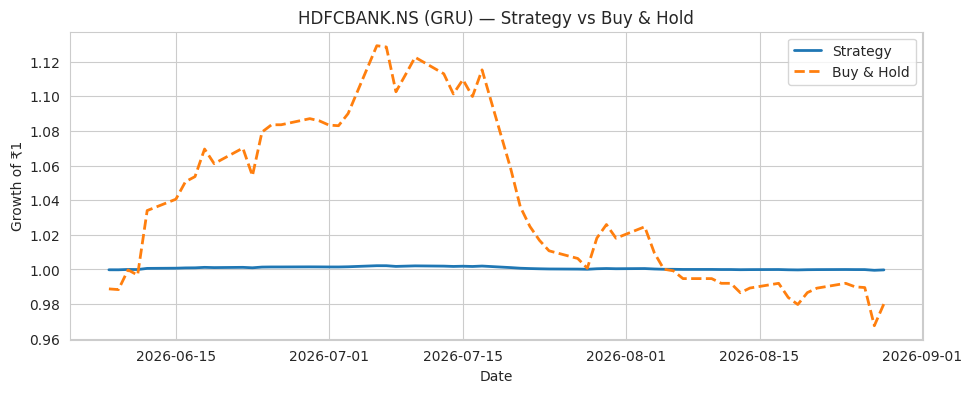

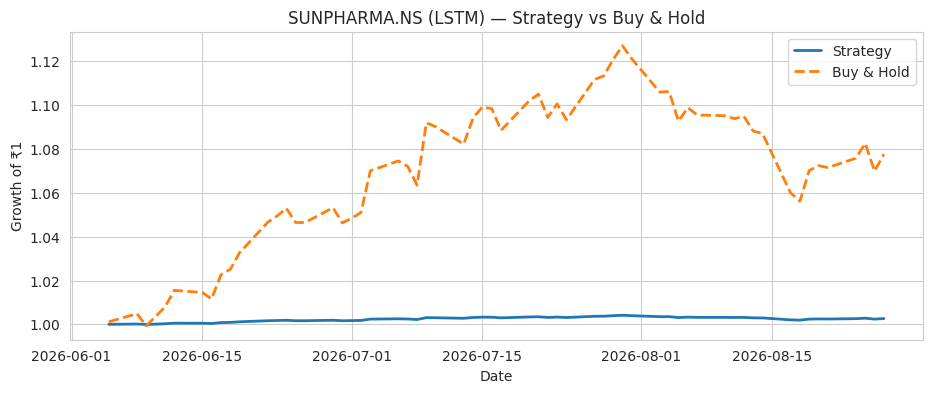

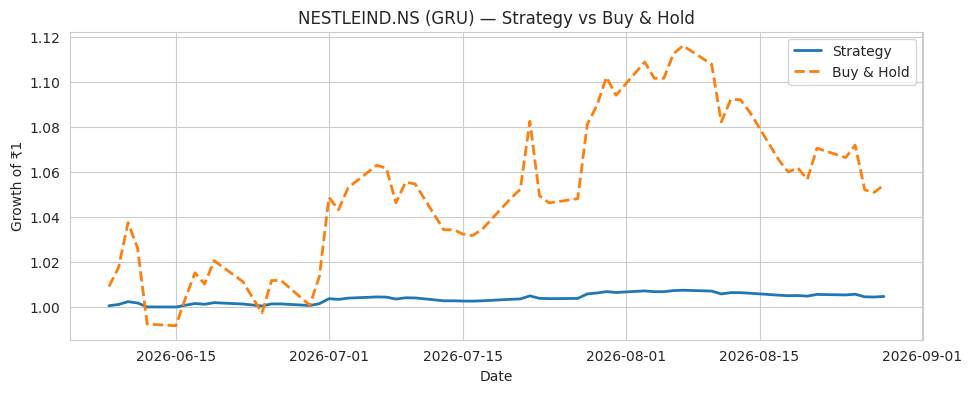

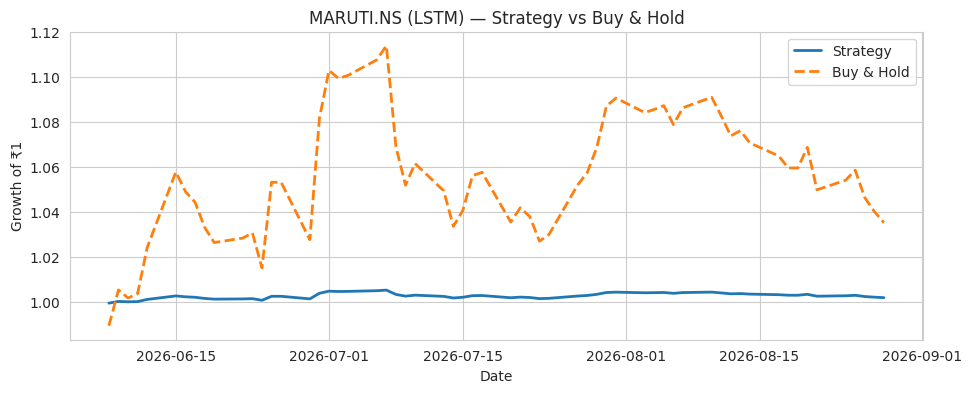

In [24]:
for ticker in STOCKS:
    bt = backtest_results[ticker]
    plt.plot(bt["test_index"], bt["equity_curve"], label="Strategy", linewidth=2)
    plt.plot(bt["test_index"], bt["buyhold_curve"], label="Buy & Hold", linewidth=2, linestyle="--")
    plt.title(f"{ticker} ({bt['model']}) — Strategy vs Buy & Hold")
    plt.xlabel("Date"); plt.ylabel("Growth of ₹1")
    plt.legend(); plt.show()


## 11. Portfolio Construction

Uses the best model for each stock (Section 9) to forecast tomorrow's price, generates a signal with the
same volatility-based threshold as the backtest, and splits the ₹10L capital across stocks — safer stocks
(lower GARCH-forecast volatility) get a bigger share.

In [25]:
def next_step_forecast(ticker, model_type):
    """Forecast tomorrow's return and convert it to a price forecast."""
    result = dl_results[ticker][model_type]
    feat_scaler = result["feat_scaler"]
    target_scaler = result["target_scaler"]

    window_features = processed[ticker]["full"][FEATURE_COLS].values[-WINDOW:]
    scaled_window = feat_scaler.transform(window_features).reshape(
        1, WINDOW, len(FEATURE_COLS)
    )

    pred_scaled = result["model"].predict(scaled_window, verbose=0)
    pred_return = float(
        target_scaler.inverse_transform(pred_scaled)[0, 0]
    )

    last_close = float(processed[ticker]["full"]["Close"].iloc[-1])
    predicted_price = last_close * np.exp(pred_return)

    return predicted_price, pred_return


def generate_signal(predicted_return):
    if predicted_return > 0:
        return "BUY"
    elif predicted_return < 0:
        return "SELL"
    return "HOLD"


portfolio_rows = []

for ticker in STOCKS:
    best_model = comparison_df.loc[ticker, "Best_Model"]
    if best_model not in MODEL_TYPES:
        best_model = min(MODEL_TYPES, key=lambda m: dl_results[ticker][m]["rmse"])

    current_price = float(processed[ticker]["full"]["Close"].iloc[-1])
    predicted_price, pred_return = next_step_forecast(ticker, best_model)

    portfolio_rows.append({
        "Stock": ticker,
        "Best_Model": best_model,
        "Current_Price": current_price,
        "Predicted_Price": predicted_price,
        "Predicted_Return_%": pred_return * 100,
        "Signal": generate_signal(pred_return),
        "GARCH_Forecast_Annual_Vol": garch_results[ticker]["annual_vol_forecast"],
    })

portfolio_df = pd.DataFrame(portfolio_rows)
portfolio_df


,Stock,Best_Model,Current_Price,Predicted_Price,Predicted_Return_%,Signal,GARCH_Forecast_Annual_Vol
0,TCS.NS,LSTM,2342.000000,2343.170391,0.049962,BUY,0.237070
1,HDFCBANK.NS,GRU,720.299988,720.429409,0.017966,BUY,0.215051
2,SUNPHARMA.NS,LSTM,1913.300049,1913.998269,0.036486,BUY,0.241457
3,NESTLEIND.NS,GRU,1454.599976,1455.858450,0.086479,BUY,0.221499
4,MARUTI.NS,LSTM,13376.000000,13382.341173,0.047396,BUY,0.256782


In [26]:
portfolio_df["Inverse_Volatility"] = 1 / portfolio_df["GARCH_Forecast_Annual_Vol"]
portfolio_df["Weight"] = portfolio_df["Inverse_Volatility"] / portfolio_df["Inverse_Volatility"].sum()
portfolio_df["Allocation"] = portfolio_df["Weight"] * CAPITAL

final_portfolio = portfolio_df[
    ["Stock", "Best_Model", "Predicted_Return_%", "GARCH_Forecast_Annual_Vol", "Weight", "Allocation", "Signal"]
]
final_portfolio


,Stock,Best_Model,Predicted_Return_%,GARCH_Forecast_Annual_Vol,Weight,Allocation,Signal
0,TCS.NS,LSTM,0.049962,0.237070,0.196938,196937.602358,BUY
1,HDFCBANK.NS,GRU,0.017966,0.215051,0.217102,217102.120304,BUY
2,SUNPHARMA.NS,LSTM,0.036486,0.241457,0.193359,193359.458000,BUY
3,NESTLEIND.NS,GRU,0.086479,0.221499,0.210782,210781.792059,BUY
4,MARUTI.NS,LSTM,0.047396,0.256782,0.181819,181819.027279,BUY


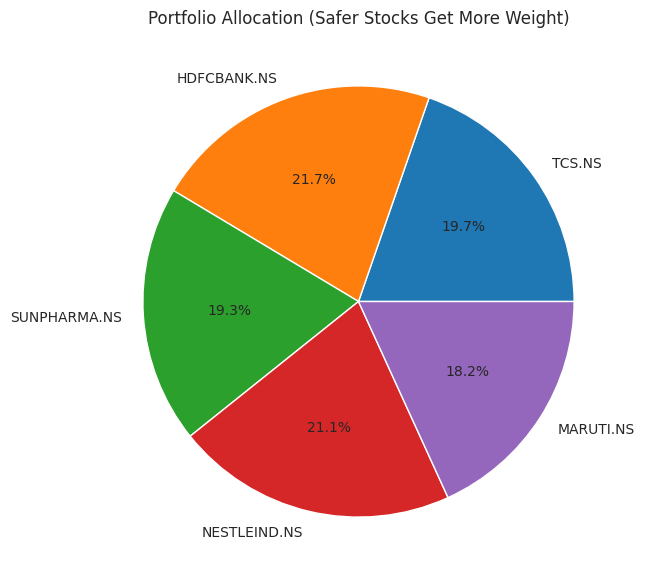

In [27]:
plt.figure(figsize=(7, 7))
plt.pie(final_portfolio["Allocation"], labels=final_portfolio["Stock"], autopct="%1.1f%%")
plt.title("Portfolio Allocation (Safer Stocks Get More Weight)")
plt.show()


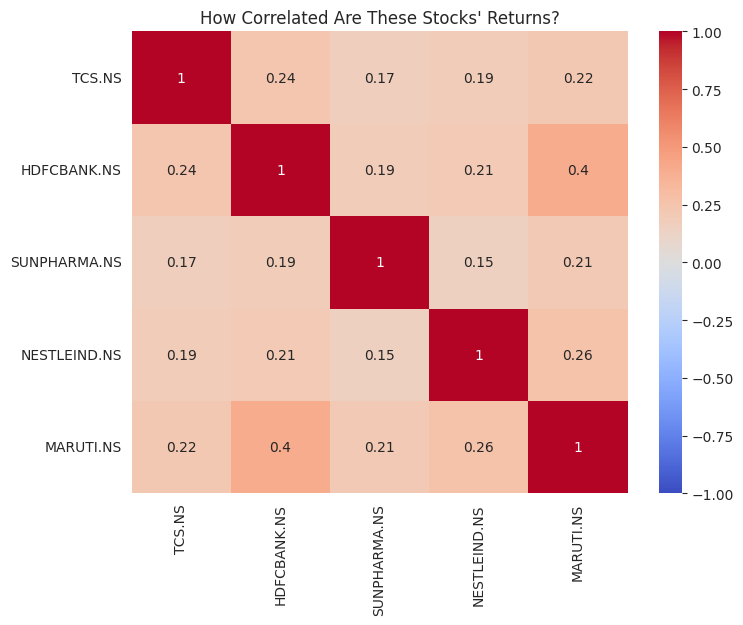

In [28]:
returns_df = pd.DataFrame({ticker: processed[ticker]["full"]["Log_Returns"] for ticker in STOCKS})
correlation_matrix = returns_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("How Correlated Are These Stocks' Returns?")
plt.show()


In [29]:
final_portfolio.to_csv("final_portfolio.csv", index=False)
comparison_df.to_csv("model_comparison.csv")
backtest_df.to_csv("backtest_results.csv")
print("Saved: final_portfolio.csv, model_comparison.csv, backtest_results.csv")


Saved: final_portfolio.csv, model_comparison.csv, backtest_results.csv
